#### Importing packages

In [ ]:
# Install necessary packages
!pip install chembl_webresource_client tensorflow numpy pandas matplotlib seaborn rdkit keras-tuner scikit-learn
!pip install rdkit
!pip install pubchempy
!pip install mordred

In [2]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
from glob import glob

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing necessary modules from the RDKit library
# Importing the Chem module for basic chemistry functions
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, PandasTools, MACCSkeys, AtomPairs, rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.Chem.rdmolops import PatternFingerprint
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem.AtomPairs.Pairs import GetAtomPairFingerprintAsBitVect
pd.set_option('display.max_rows', None)

# Importing various submodules from rdkit.Chem for chemical descriptors and fingerprints
from rdkit.Chem import Descriptors   # For calculating molecular descriptors
from rdkit.Chem import MACCSkeys      # For generating MACCS keys fingerprints
from rdkit.Chem import AllChem          # For various chemical functions, including fingerprint generation
from rdkit.Chem import rdMolDescriptors   # For calculating more advanced molecular descriptors

# Importing the Fingerprinter class from rdkit.Chem.EState for EState fingerprints
from rdkit.Chem.EState import Fingerprinter as EStateFingerprinter

# Library to split data in train and test
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
import xgboost as xgb
import lightgbm as lgb
import pubchempy as pcp
from rdkit.Chem import Crippen

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    matthews_corrcoef,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

# Importing the new_client module from the ChEMBL web resource client library
# The ChEMBL web resource client is used to access the ChEMBL database, a large bioactivity database
from chembl_webresource_client.new_client import new_client


from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, roc_auc_score, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier # Import MLPClassifier


from rdkit.Chem import AllChem, rdFingerprintGenerator

pd.set_option('display.max_columns', 2000)
warnings.filterwarnings("ignore")
sns.set(style='whitegrid')


#### GC-MS Results cleaning

In [ ]:
gc_ms_results = pd.read_csv('/content/peak table.csv')

In [ ]:
gc_ms_results.head()

,Name,R.T. (min),Similarity,Formula,Area,Peak S/N,Base Mass
0,Butanoic acid,7.03282,804.0,C4H8O2,814602,155,60.06
1,"1,2-Hydrazinedicarboxaldehyde",7.05605,722.0,C2H4N2O2,814602,36,60.06
2,L-Glutamine tert-butyl ester,7.17222,682.0,C9H18N2O3,812714,23,44.07
3,Hexanoic acid,7.23687,912.0,C6H12O2,62330432,3442,60.06
4,"1,3-Dioxolane-2-methanol",7.24332,786.0,C4H8O3,2744983,72,73.06


In [ ]:
gc_ms_results

,Name,R.T. (min),Similarity,Formula,Area,Peak S/N,Base Mass
0,Butanoic acid,7.03282,804.0,C4H8O2,814602,155,60.06
1,"1,2-Hydrazinedicarboxaldehyde",7.05605,722.0,C2H4N2O2,814602,36,60.06
2,L-Glutamine tert-butyl ester,7.17222,682.0,C9H18N2O3,812714,23,44.07
3,Hexanoic acid,7.23687,912.0,C6H12O2,62330432,3442,60.06
4,"1,3-Dioxolane-2-methanol",7.24332,786.0,C4H8O3,2744983,72,73.06
5,"Propanoic acid, 2-methyl-, 3-methylbutyl ester",7.30671,812.0,C9H18O2,3350355,217,70.11
6,"Benzene, 1-methyl-3-(1-methylethyl)-",7.59482,884.0,C10H14,6908755,343,119.12
7,D-Limonene,7.69964,874.0,C10H16,2456632,408,68.10
8,Peak 9,7.76761,NaN,NaN,51451,23,44.03
9,Peak 10,7.81400,NaN,NaN,510584,42,55.07


In [ ]:
gc_ms_results.shape

(368, 7)

In [ ]:
# Remove rows where Formula is empty, NaN
gc_ms_results = gc_ms_results[gc_ms_results['Formula'].notna() & (gc_ms_results['Formula'].str.strip() != "")]


In [ ]:
gc_ms_results = gc_ms_results.reset_index(drop=True)

In [ ]:
gc_ms_results.shape

(264, 7)

In [ ]:
gc_ms_results["Area_percent"] = gc_ms_results["Area"] / gc_ms_results["Area"].sum() * 100


In [ ]:
gc_ms_results

,Name,R.T. (min),Similarity,Formula,Area,Peak S/N,Base Mass,Area_percent
0,Butanoic acid,7.03282,804.0,C4H8O2,814602,155,60.06,0.093351
1,"1,2-Hydrazinedicarboxaldehyde",7.05605,722.0,C2H4N2O2,814602,36,60.06,0.093351
2,L-Glutamine tert-butyl ester,7.17222,682.0,C9H18N2O3,812714,23,44.07,0.093135
3,Hexanoic acid,7.23687,912.0,C6H12O2,62330432,3442,60.06,7.142902
4,"1,3-Dioxolane-2-methanol",7.24332,786.0,C4H8O3,2744983,72,73.06,0.314568
5,"Propanoic acid, 2-methyl-, 3-methylbutyl ester",7.30671,812.0,C9H18O2,3350355,217,70.11,0.383942
6,"Benzene, 1-methyl-3-(1-methylethyl)-",7.59482,884.0,C10H14,6908755,343,119.12,0.791725
7,D-Limonene,7.69964,874.0,C10H16,2456632,408,68.10,0.281524
8,"1,3-Cyclohexanedione, 2,2,5,5-tetramethyl-",7.95651,621.0,C10H16O2,349454,32,83.07,0.040047
9,Benzeneacetaldehyde,8.01326,849.0,C8H8O,5094950,641,91.08,0.583868


In [ ]:
# Save the cleaned dataframe
gc_ms_results.to_csv("gc_ms_resultsJAN.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
gc_ms_resultss = pd.read_csv('/content/gc_ms_results_with_SMILES_CID.csv')

In [ ]:
gc_ms_resultss

,Name,R.T. (min),Similarity,Formula,Area,Peak S/N,Base Mass,Area_percent,SMILES,PubChem_CID
0,Butanoic acid,7.03282,804.0,C4H8O2,814602,155,60.06,0.093351,CCCC(=O)O,264.0
1,"1,2-Hydrazinedicarboxaldehyde",7.05605,722.0,C2H4N2O2,814602,36,60.06,0.093351,C(=O)NNC=O,12342.0
2,L-Glutamine tert-butyl ester,7.17222,682.0,C9H18N2O3,812714,23,44.07,0.093135,NaN,NaN
3,Hexanoic acid,7.23687,912.0,C6H12O2,62330432,3442,60.06,7.142902,CCCCCC(=O)O,8892.0
4,"1,3-Dioxolane-2-methanol",7.24332,786.0,C4H8O3,2744983,72,73.06,0.314568,C1COC(O1)CO,294864.0
5,"Propanoic acid, 2-methyl-, 3-methylbutyl ester",7.30671,812.0,C9H18O2,3350355,217,70.11,0.383942,CC(C)CCOC(=O)C(C)C,519786.0
6,"Benzene, 1-methyl-3-(1-methylethyl)-",7.59482,884.0,C10H14,6908755,343,119.12,0.791725,CC1=CC(=CC=C1)C(C)C,10812.0
7,D-Limonene,7.69964,874.0,C10H16,2456632,408,68.10,0.281524,CC1=CCC(CC1)C(=C)C,440917.0
8,"1,3-Cyclohexanedione, 2,2,5,5-tetramethyl-",7.95651,621.0,C10H16O2,349454,32,83.07,0.040047,CC1(CC(=O)C(C(=O)C1)(C)C)C,69706.0
9,Benzeneacetaldehyde,8.01326,849.0,C8H8O,5094950,641,91.08,0.583868,C1=CC=C(C=C1)CC=O,998.0


In [ ]:
top10 = gc_ms_resultss.nlargest(10, "Area_percent")
print(top10)

                                        Name  R.T. (min)  Similarity  \
228               trans-13-Octadecenoic acid    21.12480       906.0   
202                      n-Hexadecanoic acid    19.57850       936.0   
30                       Phenylethyl Alcohol     9.32492       952.0   
3                              Hexanoic acid     7.23687       912.0   
205           Hexadecanoic acid, ethyl ester    19.74780       911.0   
230   9,12-Octadecadienoic acid, ethyl ester    21.19790       915.0   
258                   9-Octadecenamide, (Z)-    23.79600       906.0   
227         9,12-Octadecadienoic acid (Z,Z)-    21.08490       808.0   
231      (E)-9-Octadecenoic acid ethyl ester    21.25320       899.0   
252  trans-9-Octadecenoic acid, pentyl ester    22.95770       844.0   

      Formula       Area  Peak S/N  Base Mass  Area_percent  \
228  C18H34O2  140016507      1056      55.10     16.045520   
202  C16H32O2   66143224      3776      73.07      7.579838   
30     C8H10O   64

In [ ]:
lowest = gc_ms_resultss.nsmallest(1, "Area_percent")
print(lowest)

            Name  R.T. (min)  Similarity    Formula   Area  Peak S/N  \
92  Dasycarpidol     12.7897       602.0  C17H22N2O  17321        15   

    Base Mass  Area_percent                                SMILES  PubChem_CID  
92     105.09      0.001985  CCC1C2CCN(C1C3=C(C2O)NC4=CC=CC=C43)C     576461.0  


In [ ]:
import pandas as pd
import numpy as np

# Function to assign chemical class based on compound name
def classify_compound(name):
    name = name.lower()

    if any(x in name for x in ["alkane", "decane", "nonane", "hexane", "heptane", "octane"]):
        return "Alkanes"
    if any(x in name for x in ["acid", "oic"]):
        return "Fatty acids / Carboxylic acids"
    if any(x in name for x in ["ester", "ate"]):
        return "Esters"
    if any(x in name for x in ["alcohol", "ol"]):
        return "Alcohols"
    if any(x in name for x in ["aldehyde"]):
        return "Aldehydes"
    if any(x in name for x in ["ketone", "one"]):
        return "Ketones"
    if any(x in name for x in ["phenol", "benzene", "phenyl"]):
        return "Phenolics / Aromatics"
    if any(x in name for x in ["terp", "limonene", "caren", "phytol"]):
        return "Terpenoids"
    if any(x in name for x in ["amide"]):
        return "Amides"
    if any(x in name for x in ["furan", "pyran"]):
        return "Furan / Pyran derivatives"
    if any(x in name for x in ["siloxane", "silane"]):
        return "Siloxanes"

    return "Others"

# Apply classification
gc_ms_resultss["Class"] = gc_ms_resultss["Name"].apply(classify_compound)

# Calculate total % per class
class_percentages = (
    gc_ms_resultss.groupby("Class")["Area_percent"]
    .sum()
    .sort_values(ascending=False)
)

class_percentages

,Area_percent
Class,
Fatty acids / Carboxylic acids,59.620080
Alcohols,12.210108
Amides,7.146999
Alkanes,6.351737
Esters,4.318054
Others,3.416426
Ketones,2.939553
Phenolics / Aromatics,1.650341
Siloxanes,1.264591


In [ ]:
s
# pip install pubchempy pandas

import pubchempy as pcp
import pandas as pd

# Your existing dataframe
compound_names = gc_ms_results['Name'].tolist()

smiles_list = []
cid_list = []

for name in compound_names:
    try:
        results = pcp.get_compounds(name, 'name')
        if results:
            smiles_list.append(results[0].canonical_smiles)
            cid_list.append(results[0].cid)
        else:
            smiles_list.append(None)
            cid_list.append(None)
            print(f"⚠️ Not found: {name}")
    except Exception as e:
        smiles_list.append(None)
        cid_list.append(None)
        print(f"❌ Error for {name}: {e}")

# Add SMILES and PubChem CID columns to your dataframe
gc_ms_results['SMILES'] = smiles_list
gc_ms_results['PubChem_CID'] = cid_list

# Optional: Save to CSV
gc_ms_results.to_csv("gc_ms_results_with_SMILES_CID.csv", index=False)
print("✅ SMILES and PubChem CID extraction completed! Check 'gc_ms_results_with_SMILES_CID.csv'.")

⚠️ Not found: L-Glutamine tert-butyl ester
⚠️ Not found: Disulfide, bis(3-fluorobenzyl)
⚠️ Not found: 5-Amino-1-methyl-1H-pyrazole-4-carboxamide, 3TMS
⚠️ Not found: 1,2-Cyclohexanediol, 4-methyl-1-(1-methylethyl)-, (1a,2a,4a)-
⚠️ Not found: Phenylglyoxylic acid, neopentyl ester
⚠️ Not found: a-D-Glucopyranoside, methyl 2,3,4,6-tetra-O-methyl-
⚠️ Not found: Hexaborane
⚠️ Not found: tert-Butyl N-(tert-butoxy)carbamate
⚠️ Not found: 4-(2-Hydroxyethyl)piperazin-2-one, acetate
⚠️ Not found: 1,1,1-Trifluoroheptadecen-2-one
⚠️ Not found: a-D-Glucopyranoside, methyl 2,3,4,6-tetra-O-methyl-
✅ SMILES and PubChem CID extraction completed! Check 'gc_ms_results_with_SMILES_CID.csv'.


#### SMART & Cluster all compounds

In [ ]:
from rdkit import Chem
gc_ms_results['Mol'] = gc_ms_results['SMILES'].apply(lambda x: Chem.MolFromSmiles(x) if x else None)

In [ ]:
from rdkit.Chem import AllChem, DataStructs
import networkx as nx

# Only generate fingerprints for valid molecules
def safe_fp(mol):
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)

gc_ms_results['FP'] = gc_ms_results['Mol'].apply(safe_fp)

# Optional: drop rows where FP could not be generated
gc_ms_results_valid = gc_ms_results[gc_ms_results['FP'].notnull()].reset_index(drop=True)

# Build the network
G = nx.Graph()
for i, fp1 in enumerate(gc_ms_results_valid['FP']):
    G.add_node(i)
    for j, fp2 in enumerate(gc_ms_results_valid['FP']):
        if i < j and DataStructs.TanimotoSimilarity(fp1, fp2) > 0.6:
            G.add_edge(i, j)

# Detect clusters
clusters = list(nx.algorithms.community.greedy_modularity_communities(G))
cluster_ids = {node: idx for idx, cluster in enumerate(clusters) for node in cluster}

gc_ms_results_valid['Cluster'] = gc_ms_results_valid.index.map(cluster_ids)

print(f"Number of clusters: {len(clusters)}")

Number of clusters: 172


[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerator
[13:03:52] DEPRECATION WARNING: please use MorganGenerat

In [ ]:
gc_ms_results_valid['Cluster']  # cluster IDs assigned from your CSN


,Cluster
0,0
1,26
2,0
3,27
4,3
5,28
6,29
7,30
8,31
9,32


In [ ]:
import pandas as pd

# Count compounds per cluster
cluster_counts = gc_ms_results_valid['Cluster'].value_counts().sort_index()

# Total number of clusters
num_clusters = cluster_counts.shape[0]

# Identify clusters with >=150 compounds
large_clusters = cluster_counts[cluster_counts >= 150]

# Total compounds in these large clusters
compounds_in_large_clusters = large_clusters.sum()

print(f"Among the {num_clusters} clusters, {len(large_clusters)} clusters were composed of 150 or more compounds (Figure 1).")
print(f"These clusters together contain {compounds_in_large_clusters} compounds, accounting for {compounds_in_large_clusters/len(gc_ms_results_valid)*100:.2f}% of the dataset.")

# Optional: prepare a DataFrame for Figure 1 plotting
cluster_summary = pd.DataFrame({
    'Cluster_ID': cluster_counts.index,
    'Num_Compounds': cluster_counts.values,
    'Large_Cluster': cluster_counts >= 150
})

print(cluster_summary.head(10))

Among the 172 clusters, 0 clusters were composed of 150 or more compounds (Figure 1).
These clusters together contain 0 compounds, accounting for 0.00% of the dataset.
         Cluster_ID  Num_Compounds  Large_Cluster
Cluster                                          
0                 0             19          False
1                 1             15          False
2                 2              7          False
3                 3              5          False
4                 4              5          False
5                 5              5          False
6                 6              5          False
7                 7              4          False
8                 8              4          False
9                 9              3          False


In [ ]:
# Identify clusters with >=5 compounds (adjustable)
threshold = 5
large_clusters = cluster_counts[cluster_counts >= threshold]

compounds_in_large_clusters = large_clusters.sum()
num_clusters = cluster_counts.shape[0]

print(f"Among the {num_clusters} clusters, {len(large_clusters)} clusters were composed of {threshold} or more compounds (Figure 1).")
print(f"These clusters together contain {compounds_in_large_clusters} compounds, accounting for {compounds_in_large_clusters/len(gc_ms_results_valid)*100:.2f}% of the dataset.")

Among the 172 clusters, 7 clusters were composed of 5 or more compounds (Figure 1).
These clusters together contain 61 compounds, accounting for 24.11% of the dataset.


In [ ]:
from rdkit import DataStructs
import numpy as np
import pandas as pd
from itertools import combinations

# Initialize lists to store results
cluster_summary = []

for cluster_id in gc_ms_results_valid['Cluster'].unique():
    cluster_data = gc_ms_results_valid[gc_ms_results_valid['Cluster'] == cluster_id]
    fps = list(cluster_data['FP'])

    # Skip clusters with fewer than 2 compounds
    if len(fps) < 2:
        continue

    # Intra-cluster similarity (average pairwise similarity within cluster)
    intra_sims = []
    for fp1, fp2 in combinations(fps, 2):
        intra_sims.append(DataStructs.TanimotoSimilarity(fp1, fp2))
    intra_mean = np.mean(intra_sims)

    # Inter-cluster similarity (average similarity to all compounds outside cluster)
    outside_fps = list(gc_ms_results_valid[gc_ms_results_valid['Cluster'] != cluster_id]['FP'])
    inter_sims = []
    for fp1 in fps:
        for fp2 in outside_fps:
            inter_sims.append(DataStructs.TanimotoSimilarity(fp1, fp2))
    inter_mean = np.mean(inter_sims)

    # Homogeneity score
    homogeneity = intra_mean / inter_mean if inter_mean != 0 else np.nan

    cluster_summary.append({
        'Cluster_ID': cluster_id,
        'Num_Compounds': len(fps),
        'Intra_Similarity': intra_mean,
        'Inter_Similarity': inter_mean,
        'Homogeneity': homogeneity
    })

# Convert to DataFrame
cluster_summary_df = pd.DataFrame(cluster_summary)

# Optionally, sort by homogeneity or intra-similarity
cluster_summary_df.sort_values(by='Intra_Similarity', ascending=False, inplace=True)

# Display top clusters
print(cluster_summary_df.head(10))

    Cluster_ID  Num_Compounds  Intra_Similarity  Inter_Similarity  Homogeneity
21          22              2               1.0          0.083444    11.984032
12          19              2               1.0          0.088515    11.297468
20           6              5               1.0          0.047405    21.095004
4            4              5               1.0          0.150260     6.655114
23          23              2               1.0          0.098700    10.131694
6            9              3               1.0          0.037909    26.378730
24          24              2               1.0          0.114834     8.708213
8           10              3               1.0          0.044569    22.437204
17          12              3               1.0          0.117545     8.507378
16          21              2               1.0          0.093697    10.672675


In [ ]:
cluster_summary_df

,Cluster_ID,Num_Compounds,Intra_Similarity,Inter_Similarity,Homogeneity
21,22,2,1.000000,0.083444,11.984032
12,19,2,1.000000,0.088515,11.297468
20,6,5,1.000000,0.047405,21.095004
4,4,5,1.000000,0.150260,6.655114
23,23,2,1.000000,0.098700,10.131694
6,9,3,1.000000,0.037909,26.378730
24,24,2,1.000000,0.114834,8.708213
8,10,3,1.000000,0.044569,22.437204
17,12,3,1.000000,0.117545,8.507378
16,21,2,1.000000,0.093697,10.672675


In [ ]:
cluster_summary_df
# Save the cleaned dataframe
cluster_summary_df.to_csv("cluster_summary_dfJAN.csv", index=False)

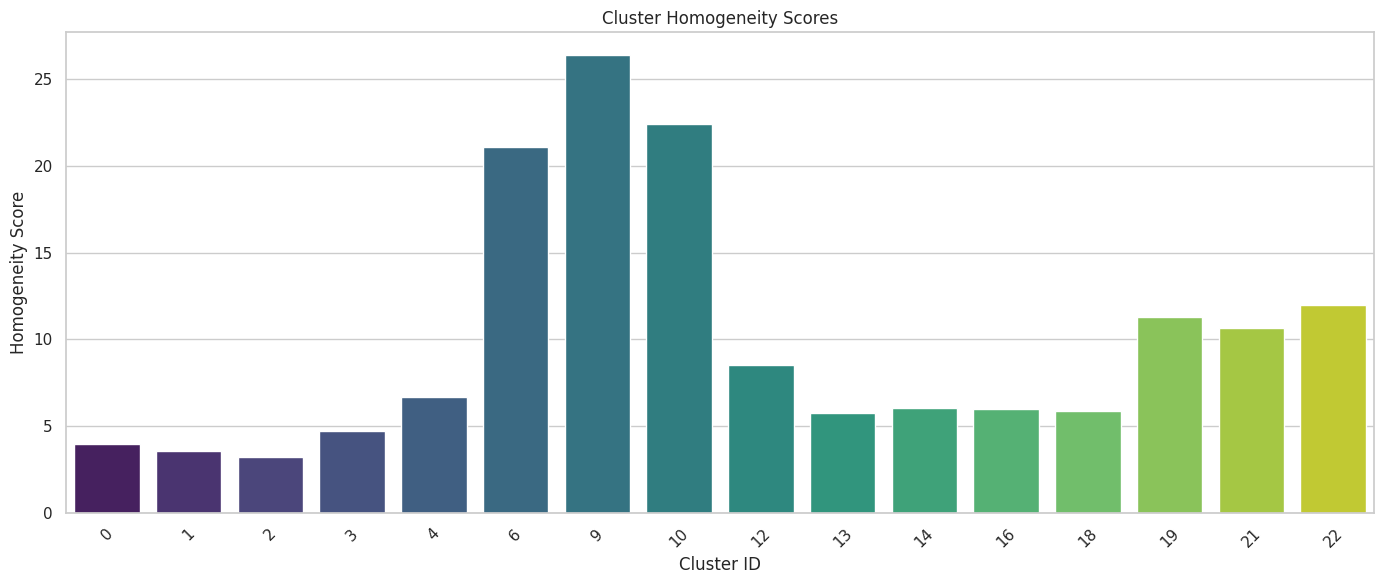

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your cluster data
data = [
    {"Cluster_ID":22,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.083444,"Homogeneity":11.984},
    {"Cluster_ID":19,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.088515,"Homogeneity":11.297},
    {"Cluster_ID":6,"Num_Compounds":5,"Intra_Similarity":1.0,"Inter_Similarity":0.047405,"Homogeneity":21.095},
    {"Cluster_ID":4,"Num_Compounds":5,"Intra_Similarity":1.0,"Inter_Similarity":0.150260,"Homogeneity":6.655},
    {"Cluster_ID":9,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.037909,"Homogeneity":26.379},
    {"Cluster_ID":10,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.044569,"Homogeneity":22.437},
    {"Cluster_ID":12,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.117545,"Homogeneity":8.507},
    {"Cluster_ID":21,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.093697,"Homogeneity":10.673},
    {"Cluster_ID":13,"Num_Compounds":2,"Intra_Similarity":0.85,"Inter_Similarity":0.147172,"Homogeneity":5.776},
    {"Cluster_ID":18,"Num_Compounds":2,"Intra_Similarity":0.7826,"Inter_Similarity":0.132892,"Homogeneity":5.889},
    {"Cluster_ID":16,"Num_Compounds":2,"Intra_Similarity":0.76,"Inter_Similarity":0.126346,"Homogeneity":6.015},
    {"Cluster_ID":14,"Num_Compounds":2,"Intra_Similarity":0.7381,"Inter_Similarity":0.122328,"Homogeneity":6.034},
    {"Cluster_ID":3,"Num_Compounds":5,"Intra_Similarity":0.7274,"Inter_Similarity":0.154543,"Homogeneity":4.707},
    {"Cluster_ID":0,"Num_Compounds":19,"Intra_Similarity":0.5952,"Inter_Similarity":0.150178,"Homogeneity":3.963},
    {"Cluster_ID":1,"Num_Compounds":15,"Intra_Similarity":0.561,"Inter_Similarity":0.155995,"Homogeneity":3.596},
    {"Cluster_ID":2,"Num_Compounds":7,"Intra_Similarity":0.5179,"Inter_Similarity":0.159881,"Homogeneity":3.239}
]

df = pd.DataFrame(data)

# --- Graph 1: Barplot of Homogeneity ---
plt.figure(figsize=(14,6))
sns.barplot(x='Cluster_ID', y='Homogeneity', data=df, palette='viridis')
plt.title("Cluster Homogeneity Scores")
plt.xlabel("Cluster ID")
plt.ylabel("Homogeneity Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



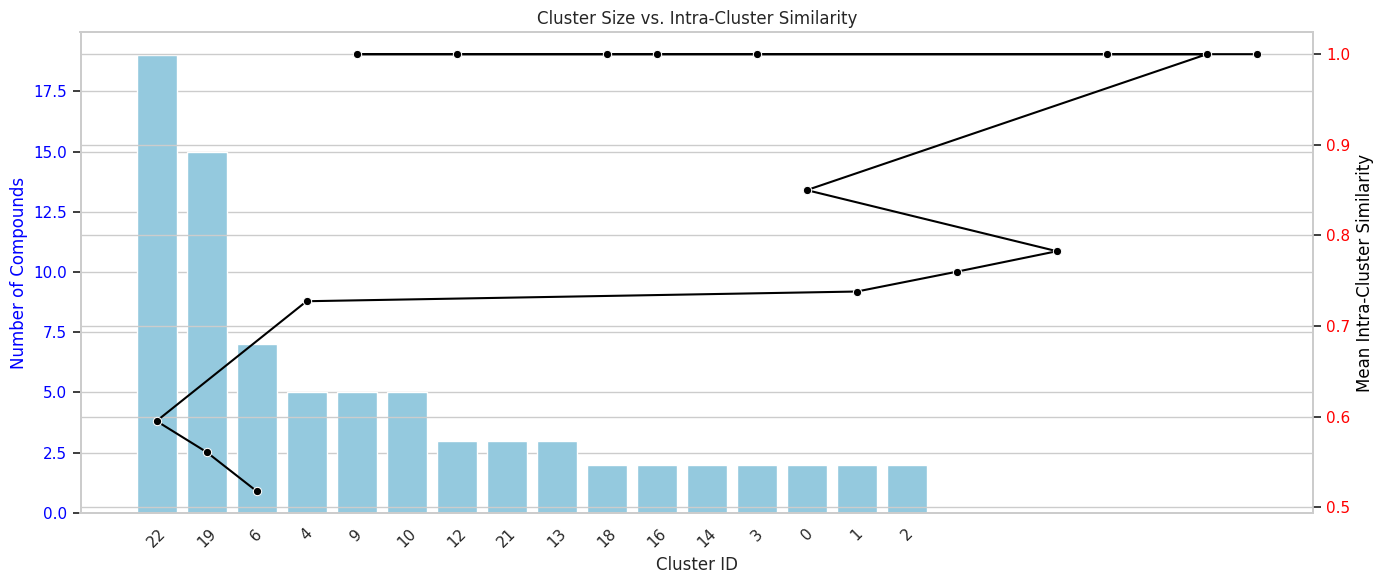

In [ ]:
# --- Graph 2: Barplot of Number of Compounds + Intra_Similarity ---
fig, ax1 = plt.subplots(figsize=(14,6))

# Bar plot: Number of compounds
sns.barplot(x='Cluster_ID', y='Num_Compounds', data=df, ax=ax1, color='skyblue')
ax1.set_xlabel("Cluster ID")
ax1.set_ylabel("Number of Compounds", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticklabels(df['Cluster_ID'], rotation=45)

# Line plot: Intra-cluster similarity
ax2 = ax1.twinx()
sns.lineplot(x='Cluster_ID', y='Intra_Similarity', data=df, ax=ax2, sort=False, color='black', marker="o")
ax2.set_ylabel("Mean Intra-Cluster Similarity", color='black')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Cluster Size vs. Intra-Cluster Similarity")
plt.tight_layout()
plt.show()


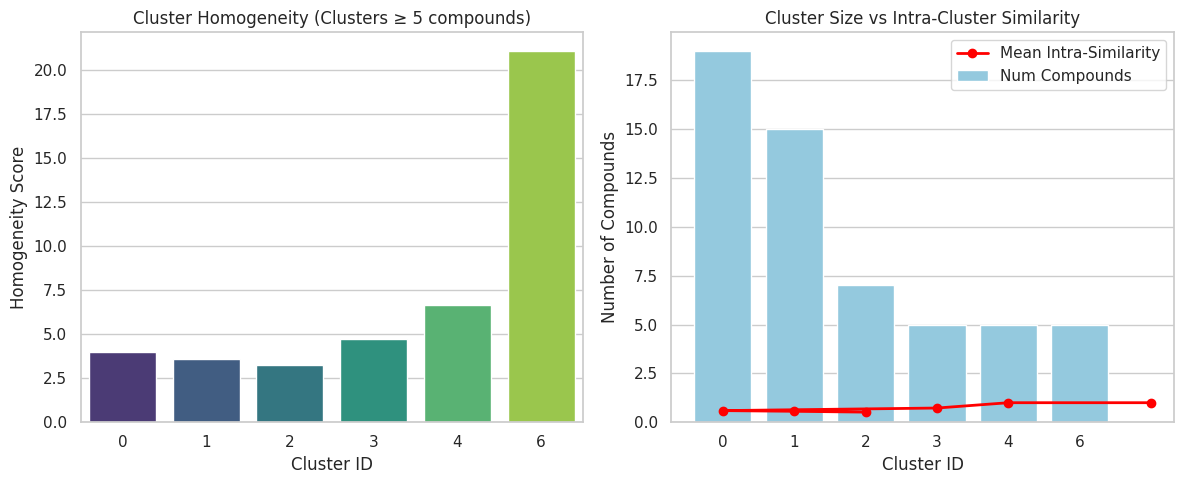

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your cluster data is in a DataFrame called df_clusters
df_clusters = pd.DataFrame([
    {"Cluster_ID":22,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.083444,"Homogeneity":11.984},
    {"Cluster_ID":19,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.088515,"Homogeneity":11.297},
    {"Cluster_ID":6,"Num_Compounds":5,"Intra_Similarity":1.0,"Inter_Similarity":0.047405,"Homogeneity":21.095},
    {"Cluster_ID":4,"Num_Compounds":5,"Intra_Similarity":1.0,"Inter_Similarity":0.150260,"Homogeneity":6.655},
    {"Cluster_ID":9,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.037909,"Homogeneity":26.379},
    {"Cluster_ID":10,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.044569,"Homogeneity":22.437},
    {"Cluster_ID":12,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.117545,"Homogeneity":8.507},
    {"Cluster_ID":21,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.093697,"Homogeneity":10.673},
    {"Cluster_ID":13,"Num_Compounds":2,"Intra_Similarity":0.85,"Inter_Similarity":0.147172,"Homogeneity":5.776},
    {"Cluster_ID":18,"Num_Compounds":2,"Intra_Similarity":0.7826,"Inter_Similarity":0.132892,"Homogeneity":5.889},
    {"Cluster_ID":16,"Num_Compounds":2,"Intra_Similarity":0.76,"Inter_Similarity":0.126346,"Homogeneity":6.015},
    {"Cluster_ID":14,"Num_Compounds":2,"Intra_Similarity":0.7381,"Inter_Similarity":0.122328,"Homogeneity":6.034},
    {"Cluster_ID":3,"Num_Compounds":5,"Intra_Similarity":0.7274,"Inter_Similarity":0.154543,"Homogeneity":4.707},
    {"Cluster_ID":0,"Num_Compounds":19,"Intra_Similarity":0.5952,"Inter_Similarity":0.150178,"Homogeneity":3.963},
    {"Cluster_ID":1,"Num_Compounds":15,"Intra_Similarity":0.561,"Inter_Similarity":0.155995,"Homogeneity":3.596},
    {"Cluster_ID":2,"Num_Compounds":7,"Intra_Similarity":0.5179,"Inter_Similarity":0.159881,"Homogeneity":3.239}

])

# Filter clusters with >=5 compounds
df_large = df_clusters[df_clusters['Num_Compounds'] >= 5]

# Plot 1: Barplot of Homogeneity
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(x='Cluster_ID', y='Homogeneity', data=df_large, palette='viridis')
plt.title('Cluster Homogeneity (Clusters ≥ 5 compounds)')
plt.xlabel('Cluster ID')
plt.ylabel('Homogeneity Score')

# Plot 2: Cluster Size vs Mean Intra-Similarity
plt.subplot(1,2,2)
sns.barplot(x='Cluster_ID', y='Num_Compounds', data=df_large, color='skyblue', label='Num Compounds')
plt.plot(df_large['Cluster_ID'], df_large['Intra_Similarity'], color='red', marker='o', linewidth=2, label='Mean Intra-Similarity')
plt.title('Cluster Size vs Intra-Cluster Similarity')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Compounds')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Plot 2: Number of compounds bar chart + Intra-Similarity line plot
sns.barplot(ax=axes[1], x='Cluster_ID', y='Num_Compounds', data=df_clusters, color='skyblue', label='Num Compounds')
axes2 = axes[1].twinx()  # Create second y-axis for intra-similarity
axes2.plot(df_clusters['Cluster_ID'], df_clusters['Intra_Similarity'], color='red', marker='o', linewidth=2, label='Mean Intra-Similarity')
axes[1].set_title('Cluster Size vs Intra-Cluster Similarity (All Clusters)')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Number of Compounds')
axes2.set_ylabel('Mean Intra-Similarity')

# Legends
axes[1].legend(loc='upper left')
axes2.legend(loc='upper right')

plt.tight_layout()
plt.show()


NameError: name 'axes' is not defined

<Axes: xlabel='Cluster_ID', ylabel='Num_Compounds'>

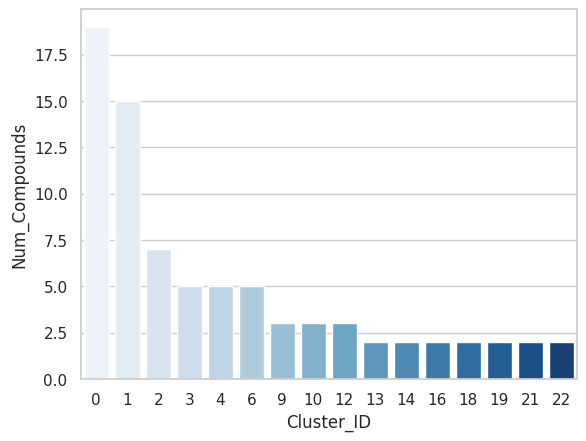

In [ ]:
sns.barplot(x='Cluster_ID', y='Num_Compounds', data=df_clusters, palette='Blues')

<Axes: xlabel='Cluster_ID', ylabel='Num_Compounds'>

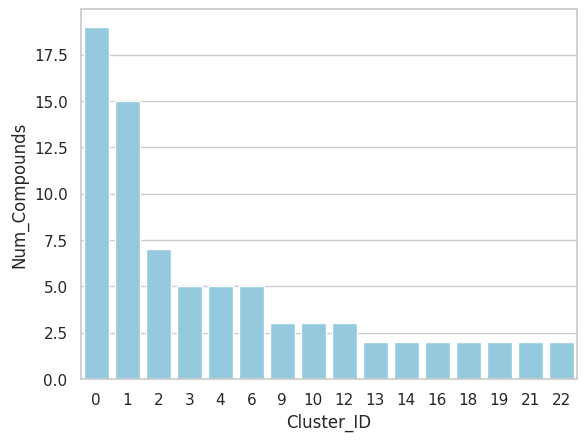

In [ ]:
sns.barplot(x='Cluster_ID', y='Num_Compounds', data=df_clusters, color='skyblue')

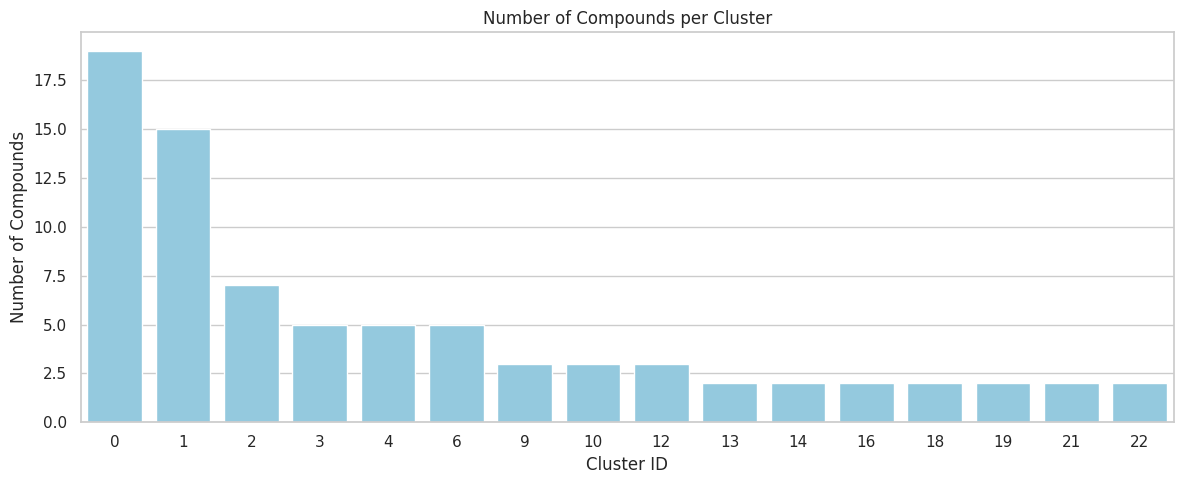

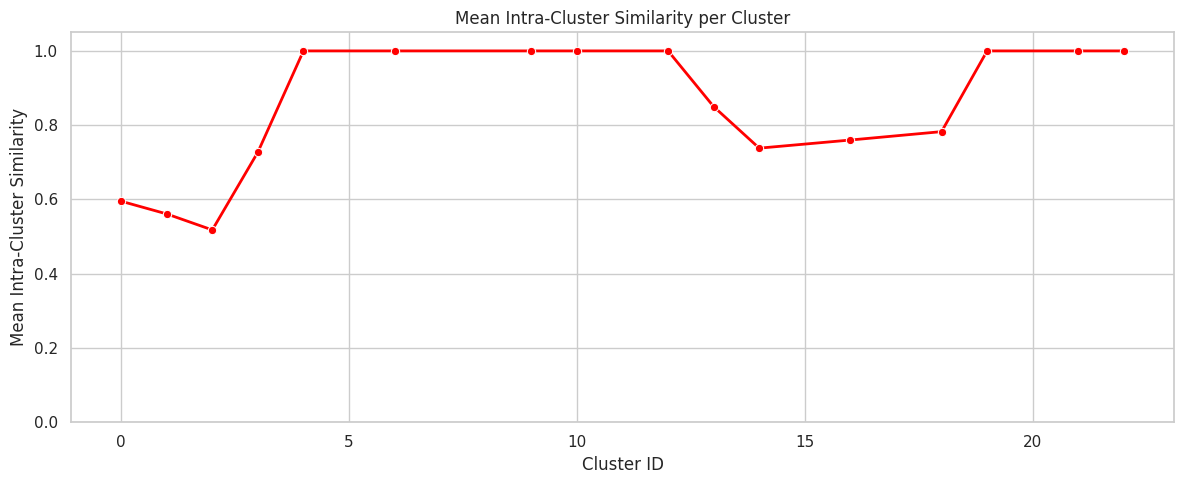

In [ ]:
# ----------------------------
# Plot 1: Bar chart - Number of Compounds per Cluster
plt.figure(figsize=(12,5))
sns.barplot(x='Cluster_ID', y='Num_Compounds', data=df_clusters, color='skyblue')
plt.title("Number of Compounds per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Compounds")
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: Line plot - Mean Intra-Cluster Similarity
plt.figure(figsize=(12,5))
sns.lineplot(x='Cluster_ID', y='Intra_Similarity', data=df_clusters, marker="o", color='red', linewidth=2)
plt.title("Mean Intra-Cluster Similarity per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Mean Intra-Cluster Similarity")
plt.ylim(0, 1.05)  # Ensures full scale for similarity (0 to 1)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example cluster data
df_clusters = pd.DataFrame([
    {"Cluster_ID":22,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.083444,"Homogeneity":11.984},
    {"Cluster_ID":19,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.088515,"Homogeneity":11.297},
    {"Cluster_ID":6,"Num_Compounds":5,"Intra_Similarity":1.0,"Inter_Similarity":0.047405,"Homogeneity":21.095},
    {"Cluster_ID":4,"Num_Compounds":5,"Intra_Similarity":1.0,"Inter_Similarity":0.150260,"Homogeneity":6.655},
    {"Cluster_ID":9,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.037909,"Homogeneity":26.379},
    {"Cluster_ID":10,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.044569,"Homogeneity":22.437},
    {"Cluster_ID":12,"Num_Compounds":3,"Intra_Similarity":1.0,"Inter_Similarity":0.117545,"Homogeneity":8.507},
    {"Cluster_ID":21,"Num_Compounds":2,"Intra_Similarity":1.0,"Inter_Similarity":0.093697,"Homogeneity":10.673},
    {"Cluster_ID":3,"Num_Compounds":5,"Intra_Similarity":0.7274,"Inter_Similarity":0.154543,"Homogeneity":4.707},
    {"Cluster_ID":0,"Num_Compounds":19,"Intra_Similarity":0.5952,"Inter_Similarity":0.150178,"Homogeneity":3.963},
    {"Cluster_ID":1,"Num_Compounds":15,"Intra_Similarity":0.561,"Inter_Similarity":0.155995,"Homogeneity":3.596},
    {"Cluster_ID":2,"Num_Compounds":7,"Intra_Similarity":0.5179,"Inter_Similarity":0.159881,"Homogeneity":3.239}
])

# ----------------------------
# Plot 1: Bar chart - Number of Compounds per Cluster
plt.figure(figsize=(12,5))
sns.barplot(x='Cluster_ID', y='Num_Compounds', data=df_clusters, palette='skyblue')
plt.title("Number of Compounds per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Compounds")
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: Line plot - Mean Intra-Cluster Similarity
plt.figure(figsize=(12,5))
sns.lineplot(x='Cluster_ID', y='Intra_Similarity', data=df_clusters, marker="o", color='red', linewidth=2)
plt.title("Mean Intra-Cluster Similarity per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Mean Intra-Cluster Similarity")
plt.ylim(0, 1.05)  # Ensures full scale for similarity (0 to 1)
plt.tight_layout()
plt.show()

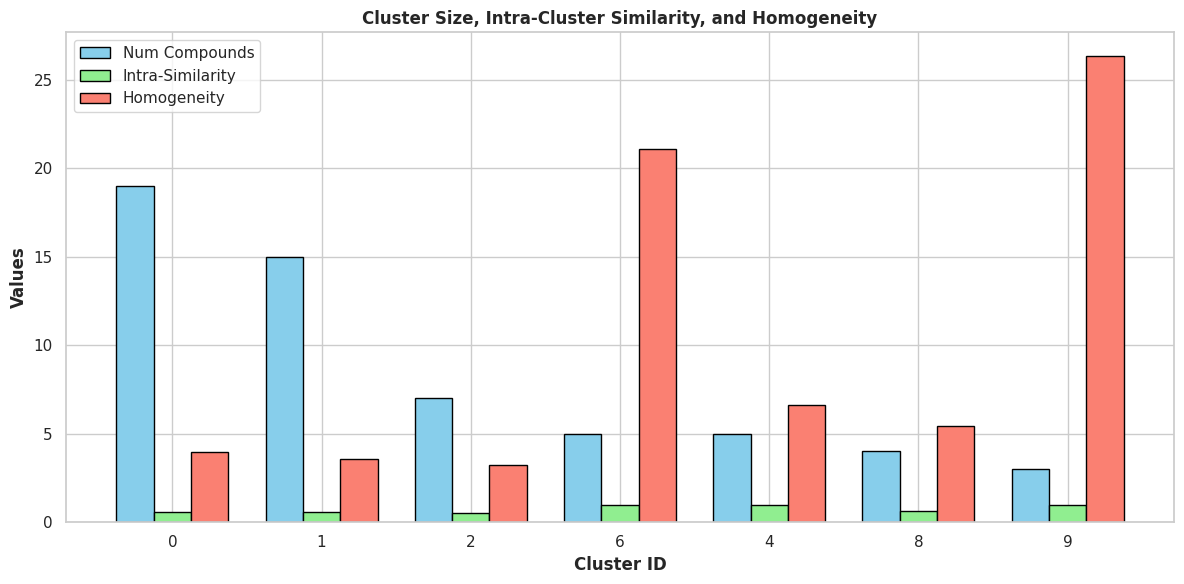

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your cluster data (parsed from JSON)
clusters_data = [
    {"Cluster_ID":0,"Num_Compounds":19,"Intra_Similarity":0.595,"Homogeneity":3.963},
    {"Cluster_ID":1,"Num_Compounds":15,"Intra_Similarity":0.561,"Homogeneity":3.596},
    {"Cluster_ID":2,"Num_Compounds":7,"Intra_Similarity":0.518,"Homogeneity":3.239},
    {"Cluster_ID":6,"Num_Compounds":5,"Intra_Similarity":1.0,"Homogeneity":21.095},
    {"Cluster_ID":4,"Num_Compounds":5,"Intra_Similarity":1.0,"Homogeneity":6.655},
    {"Cluster_ID":8,"Num_Compounds":4,"Intra_Similarity":0.658,"Homogeneity":5.469},
    {"Cluster_ID":9,"Num_Compounds":3,"Intra_Similarity":1.0,"Homogeneity":26.379},
]

df = pd.DataFrame(clusters_data)

# Set figure size
plt.figure(figsize=(12,6))

# Bar width and positions
bar_width = 0.25
r1 = range(len(df))
r2 = [x + bar_width for x in r1]
r3 = [x + 2*bar_width for x in r1]

# Plot bars
plt.bar(r1, df['Num_Compounds'], color='skyblue', width=bar_width, edgecolor='black', label='Num Compounds')
plt.bar(r2, df['Intra_Similarity'], color='lightgreen', width=bar_width, edgecolor='black', label='Intra-Similarity')
plt.bar(r3, df['Homogeneity'], color='salmon', width=bar_width, edgecolor='black', label='Homogeneity')

# Labels
plt.xlabel('Cluster ID', fontweight='bold')
plt.ylabel('Values', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(df))], df['Cluster_ID'])
plt.title('Cluster Size, Intra-Cluster Similarity, and Homogeneity', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

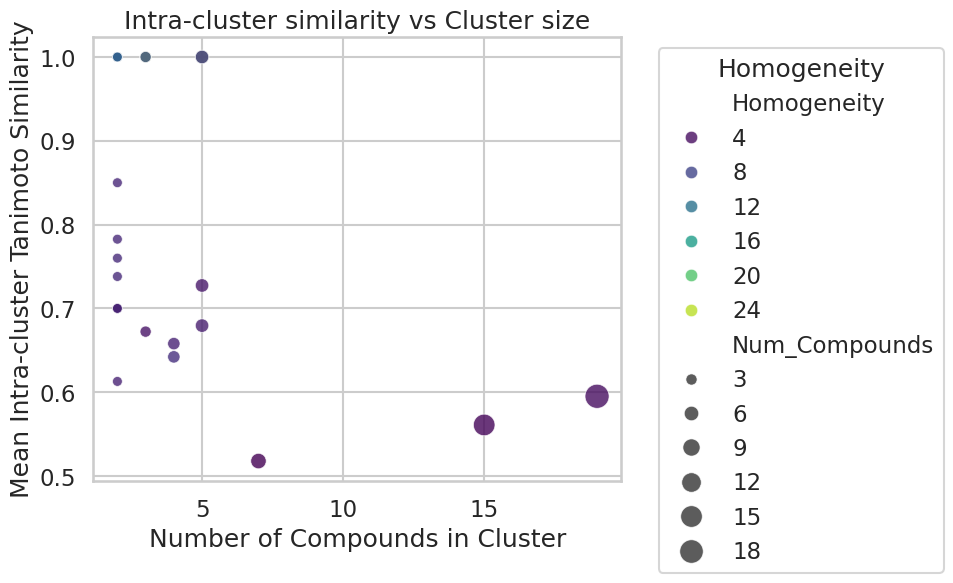

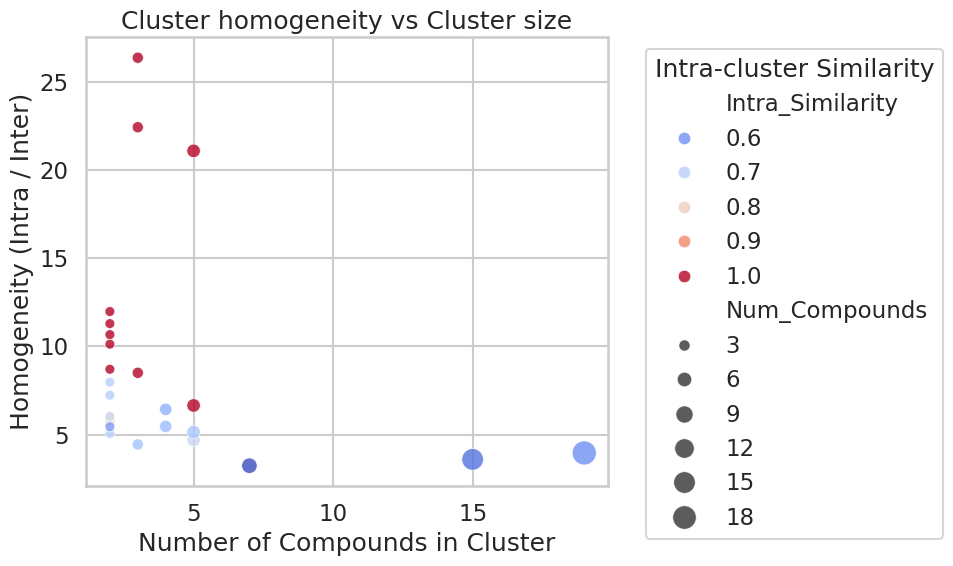

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

# Scatter plot: Intra-cluster similarity vs Cluster size
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cluster_summary_df,
    x='Num_Compounds',
    y='Intra_Similarity',
    hue='Homogeneity',
    palette='viridis',
    size='Num_Compounds',
    sizes=(50, 300),
    alpha=0.8
)
plt.title('Intra-cluster similarity vs Cluster size')
plt.xlabel('Number of Compounds in Cluster')
plt.ylabel('Mean Intra-cluster Tanimoto Similarity')
plt.legend(title='Homogeneity', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# Scatter plot: Homogeneity vs Cluster size
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=cluster_summary_df,
    x='Num_Compounds',
    y='Homogeneity',
    hue='Intra_Similarity',
    palette='coolwarm',
    size='Num_Compounds',
    sizes=(50, 300),
    alpha=0.8
)
plt.title('Cluster homogeneity vs Cluster size')
plt.xlabel('Number of Compounds in Cluster')
plt.ylabel('Homogeneity (Intra / Inter)')
plt.legend(title='Intra-cluster Similarity', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

#####Define SMARTS patterns based on literature

In [ ]:
from rdkit import Chem

# Antioxidant scaffolds
antioxidant_smarts = [
    '[OH]',    # Phenol
    'c1cc(O)c(O)cc1',  # Catechol
    'c1cc(O)cc(O)c1'   # Hydroquinone-like
]

# Antimicrobial scaffolds
antimicrobial_smarts = [
    'n1ccncc1',        # Imidazole
    'c1ncnc2n1cnc2',   # Purine-like heterocycles
    'c1ccccc1Cl',      # Chlorinated aromatics
    'C=C(C)C'          # Some terpenoid motifs
]

# Cytotoxic scaffolds
cytotoxic_smarts = [
    'O=C1C=CC(=O)C=C1',   # Quinone
    'C(=O)N',              # Amides
    'C1COC1'               # Epoxides / strained rings
]

# Convert to RDKit Mol objects
antioxidant_mols = [Chem.MolFromSmarts(s) for s in antioxidant_smarts]
antimicrobial_mols = [Chem.MolFromSmarts(s) for s in antimicrobial_smarts]
cytotoxic_mols = [Chem.MolFromSmarts(s) for s in cytotoxic_smarts]

In [ ]:
def match_any(mol, smarts_list):
    return any(mol.HasSubstructMatch(s) for s in smarts_list if s is not None)

gc_ms_results_valid['is_antioxidant'] = gc_ms_results_valid['Mol'].apply(lambda m: match_any(m, antioxidant_mols))
gc_ms_results_valid['is_antimicrobial'] = gc_ms_results_valid['Mol'].apply(lambda m: match_any(m, antimicrobial_mols))
gc_ms_results_valid['is_cytotoxic'] = gc_ms_results_valid['Mol'].apply(lambda m: match_any(m, cytotoxic_mols))

In [ ]:
antioxidant_dataset = gc_ms_results_valid[gc_ms_results_valid['is_antioxidant']].reset_index(drop=True)
antimicrobial_dataset = gc_ms_results_valid[gc_ms_results_valid['is_antimicrobial']].reset_index(drop=True)
cytotoxic_dataset = gc_ms_results_valid[gc_ms_results_valid['is_cytotoxic']].reset_index(drop=True)

print(f"Antioxidant compounds: {len(antioxidant_dataset)}")
print(f"Antimicrobial compounds: {len(antimicrobial_dataset)}")
print(f"Cytotoxic compounds: {len(cytotoxic_dataset)}")

Antioxidant compounds: 51
Antimicrobial compounds: 29
Cytotoxic compounds: 14


In [ ]:
# Find clusters containing at least one antioxidant compound
antioxidant_clusters = antioxidant_dataset['Cluster'].unique()
antimicrobial_clusters = antimicrobial_dataset['Cluster'].unique()
cytotoxic_clusters = cytotoxic_dataset['Cluster'].unique()

# Expand datasets to include all compounds in those clusters
expanded_antioxidant = gc_ms_results_valid[gc_ms_results_valid['Cluster'].isin(antioxidant_clusters)]
expanded_antimicrobial = gc_ms_results_valid[gc_ms_results_valid['Cluster'].isin(antimicrobial_clusters)]
expanded_cytotoxic = gc_ms_results_valid[gc_ms_results_valid['Cluster'].isin(cytotoxic_clusters)]

print(f"Expanded antioxidant dataset: {len(expanded_antioxidant)}")
print(f"Expanded antimicrobial dataset: {len(expanded_antimicrobial)}")
print(f"Expanded cytotoxic dataset: {len(expanded_cytotoxic)}")

Expanded antioxidant dataset: 66
Expanded antimicrobial dataset: 29
Expanded cytotoxic dataset: 28


In [ ]:
expanded_antioxidant

In [ ]:
# Save the cleaned dataframe
expanded_antioxidant.to_csv("expanded_antioxidantJAN.csv", index=False)
expanded_antimicrobial.to_csv("expanded_antimicrobialJAN.csv", index=False)
expanded_cytotoxic.to_csv("expanded_cytotoxic.csv", index=False)

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from rdkit import DataStructs

# Create graph
G = nx.Graph()
for i, fp1 in enumerate(gc_ms_results_valid['FP']):
    G.add_node(i)
    for j, fp2 in enumerate(gc_ms_results_valid['FP']):
        if i < j:
            sim = DataStructs.TanimotoSimilarity(fp1, fp2)
            if sim > 0.6:  # similarity threshold
                G.add_edge(i, j)

In [ ]:
# Define colors
colors = []
for idx, row in gc_ms_results_valid.iterrows():
    if row['Cluster'] in antioxidant_clusters:
        colors.append('green')          # antioxidants in green
    elif row['Cluster'] in antimicrobial_clusters:
        colors.append('blue')           # antimicrobials in blue
    elif row['Cluster'] in cytotoxic_clusters:
        colors.append('red')            # cytotoxic in red
    else:
        colors.append('lightgray')      # others in gray

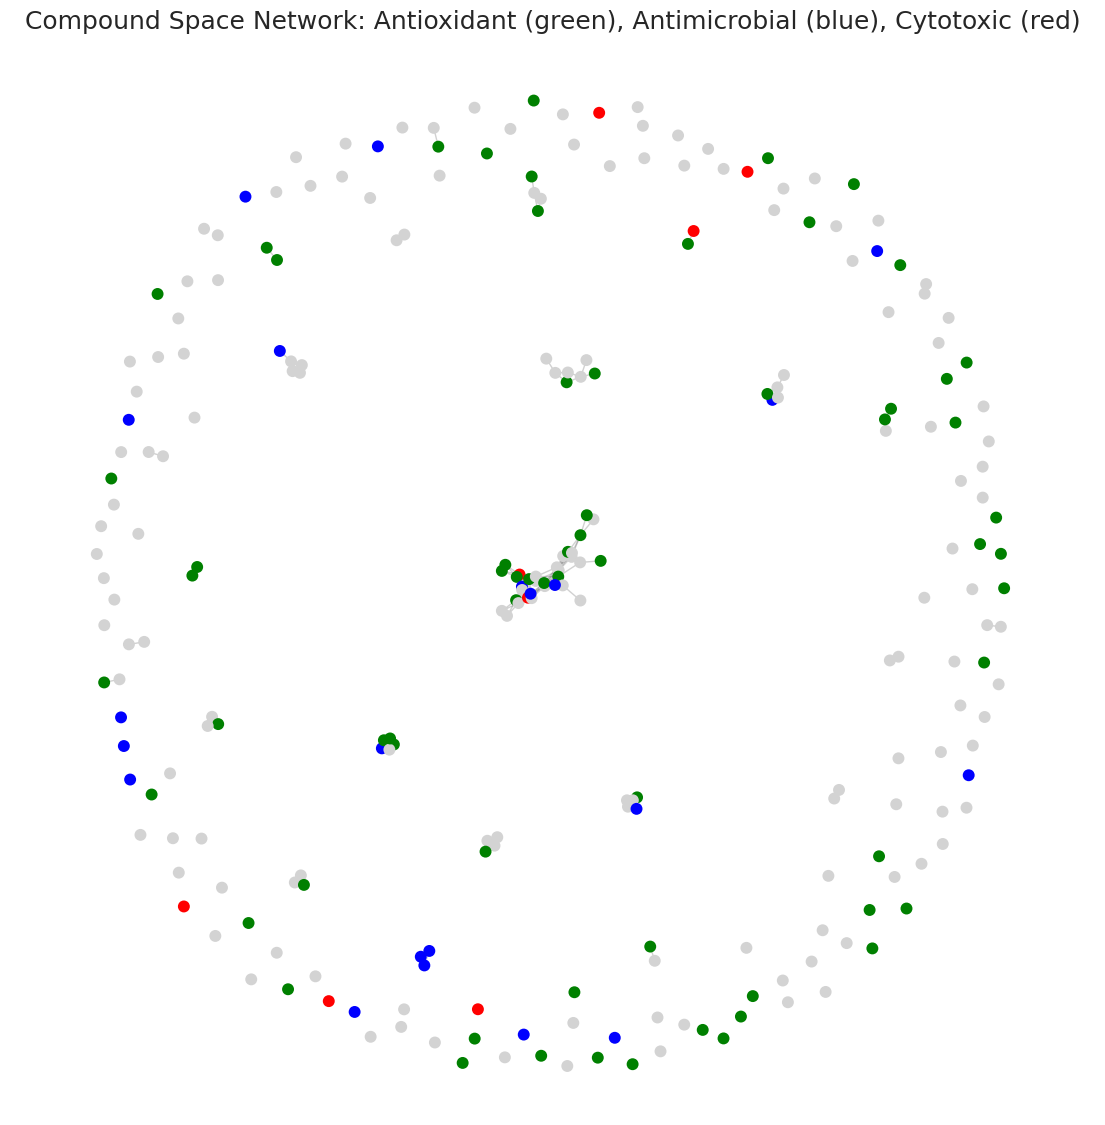

In [ ]:
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, seed=42)  # force-directed layout
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50)
nx.draw_networkx_edges(G, pos, alpha=0.2)
plt.title("Compound Space Network: Antioxidant (green), Antimicrobial (blue), Cytotoxic (red)")
plt.axis('off')
plt.show()

#### WORD DOCUMENT FOR ALL FOR MANUSCRIPT

In [3]:
!pip install python-docx
from docx import Document

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.2 MB/s eta 0:00:00


In [ ]:
!pip install python-docx

from docx import Document

# -----------------------------
# Initialize Word document
# -----------------------------
doc = Document()
doc.add_heading("GC-MS Compound Bioactivities", level=0)

# -----------------------------
# Helper function to add DataFrame as table
# -----------------------------
def add_df_to_doc(df, title):
    doc.add_heading(title, level=1)
    table = doc.add_table(rows=1, cols=len(df.columns))
    table.style = "Table Grid"

    # Add header row
    hdr_cells = table.rows[0].cells
    for i, col_name in enumerate(df.columns):
        hdr_cells[i].text = str(col_name)

    # Add DataFrame rows
    for _, row in df.iterrows():
        row_cells = table.add_row().cells
        for i, value in enumerate(row):
            row_cells[i].text = str(value)

# -----------------------------
# Add each DataFrame
# -----------------------------
add_df_to_doc(df_gc_ms[df_gc_ms["Antioxidant"]], "Antioxidant Compounds")
add_df_to_doc(df_gc_ms[df_gc_ms["Antimicrobial"]], "Antimicrobial Compounds")
add_df_to_doc(df_gc_ms[df_gc_ms["Other"]], "Other Bioactivity Compounds")
add_df_to_doc(master_df, "Master Bioactivity Compounds")
add_df_to_doc(df_gc_ms, "All GC-MS Compounds")

# -----------------------------
# Save Word document
# -----------------------------
doc.save("GCMS_Bioactivity_Report.docx")
print("✅ Word document created successfully!")

In [ ]:
from docx import Document

# Export antioxidant_df to Word
doc = Document()
doc.add_heading("Cytotoxic Dataset", level=1)

# Create table
table = doc.add_table(rows=1, cols=len(cytotoxic_df.columns))
header_cells = table.rows[0].cells

# Add header names
for i, col in enumerate(cytotoxic_df.columns):
    header_cells[i].text = str(col)

# Add rows
for _, row in cytotoxic_df.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Save the document
doc.save("cytotoxic_df.docx")

print("Saved as cytotoxic_df.docx")

Saved as cytotoxic_df.docx


In [ ]:
from docx import Document

# Export antioxidant_df to Word
doc = Document()
doc.add_heading("AntiMicrobial Dataset", level=1)

# Create table
table = doc.add_table(rows=1, cols=len(antimicrobial_df.columns))
header_cells = table.rows[0].cells

# Add header names
for i, col in enumerate(antimicrobial_df.columns):
    header_cells[i].text = str(col)

# Add rows
for _, row in antimicrobial_df.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# Save the document
doc.save("antimicrobial_df.docx")

print("Saved as antimicrobial_df.docx")

Saved as antimicrobial_df.docx


#### Scaffold-Based Drug Discovery Analysis

##### Bioactivity Dataset

In [ ]:
antioxidant_df = pd.read_csv('/content/expanded_antioxidantJAN.csv')

In [ ]:
antimicrobial_df = pd.read_csv('/content/expanded_antimicrobialJAN.csv')

In [ ]:
cytotoxic_df = pd.read_csv('/content/expanded_cytotoxic.csv')

In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import Draw
import pandas as pd
import numpy as np
from collections import Counter
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter
import numpy as np
import pandas as pd

# ---------- SAFELY PARSE MOLECULES ----------
def safe_mol(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles, sanitize=False)
        if mol is None:
            return None
        try:
            Chem.SanitizeMol(mol)
        except:
            return None
        return mol
    except:
        return None

# ---------- BEMIS–MURCKO SCAFFOLD ----------
def compute_bm_scaffold(smiles):
    mol = safe_mol(smiles)
    if mol is None:
        return None
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except:
        return None

# ---------- CYCLIC SKELETON ----------
def cyclic_skeleton(smiles):
    mol = safe_mol(smiles)
    if mol is None:
        return None
    try:
        skel = MurckoScaffold.MakeScaffoldGeneric(mol)
        return Chem.MolToSmiles(skel)
    except:
        return None

# ---------- SHANNON ENTROPY ----------
def shannon_entropy(counter_obj):
    counts = np.array(list(counter_obj.values()))
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

# ===============================================================
#                 FIXED + STRONGER MAIN FUNCTION
# ===============================================================
def scaffold_analysis(df, smiles_col="SMILES", dataset_name="Dataset"):

    # ✔ Always make a clean copy
    df = df.copy()

    # ✔ Compute molecules safely
    df["MOL"] = df[smiles_col].apply(safe_mol)

    # ✔ Log invalid SMILES
    invalid = df[df["MOL"].isna()]
    if len(invalid) > 0:
        print(f"⚠️ {len(invalid)} invalid SMILES removed from {dataset_name}:")
        display(invalid[[smiles_col]].head(10))

    df = df.dropna(subset=["MOL"])

    # ✔ Compute scaffolds (safe)
    df["BM_SCAFFOLD"] = df[smiles_col].apply(compute_bm_scaffold)
    df = df[df["BM_SCAFFOLD"].notna() & (df["BM_SCAFFOLD"] != "")]

    # ✔ Cyclic skeleton (safe)
    df["CYCLIC_SKEL"] = df[smiles_col].apply(cyclic_skeleton)

    # ------------ METRICS -------------
    N = len(df)
    scaffold_counts = Counter(df["BM_SCAFFOLD"])
    Ns = len(scaffold_counts)
    Nss = sum(1 for c in scaffold_counts.values() if c == 1)
    Ncsk = df["CYCLIC_SKEL"].nunique()

    results = {
        "Dataset": dataset_name,
        "Molecules (N)": N,
        "Unique scaffolds (Ns)": Ns,
        "Singleton scaffolds (Nss)": Nss,
        "Cyclic skeletons (Ncsk)": Ncsk,
        "Ns/N": Ns / N if N > 0 else 0,
        "Nss/N": Nss / N if N > 0 else 0,
        "Ncsk/N": Ncsk / N if N > 0 else 0,
        "Scaffold diversity (N/M)": Ns / N if N > 0 else 0,
        "Singleton diversity (Nsing/M)": Nss / N if N > 0 else 0,
        "Shannon entropy": shannon_entropy(scaffold_counts) if Ns > 0 else 0
    }

    return df, scaffold_counts, results


In [ ]:
antiox_df, antiox_counts, antiox_results = scaffold_analysis(
    antioxidant_df,
    smiles_col="SMILES",
    dataset_name="Antioxidant"
)

[21:49:19] Explicit valence for atom # 5 C, 5, is greater than permitted


##### Visualization

In [ ]:
antiox_df = antiox_df[antiox_df["BM_SCAFFOLD"].notna() & (antiox_df["BM_SCAFFOLD"] != "")]

In [ ]:
antiox_counts = {s: c for s, c in antiox_counts.items() if s not in [None, "", "*", " "]}

In [ ]:
#plot_top10_bar
def plot_top10_bar(scaffold_counts, title):
    top10 = scaffold_counts.most_common(10)

    labels = [f"Scaffold {i+1}" for i in range(10)]
    freqs = [c for _, c in top10]

    plt.figure(figsize=(7,5))
    cmap = sns.color_palette("rocket", 10)
    sns.barplot(x=freqs, y=labels, palette=cmap)
    plt.xlabel("Frequency")
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_top10_structures(scaffold_counts, title):
    top10 = scaffold_counts.most_common(10)
    scaffolds = [Chem.MolFromSmiles(s) for s,_ in top10]
    labels = [f"{i+1}\nFreq: {c}" for i, (_,c) in enumerate(top10)]

    img = Draw.MolsToGridImage(
        scaffolds,
        legends=labels,
        molsPerRow=5,
        subImgSize=(300,300)
    )
    display(img)

##### Antioxidant Scaffold Analysis

[21:49:37] Explicit valence for atom # 5 C, 5, is greater than permitted


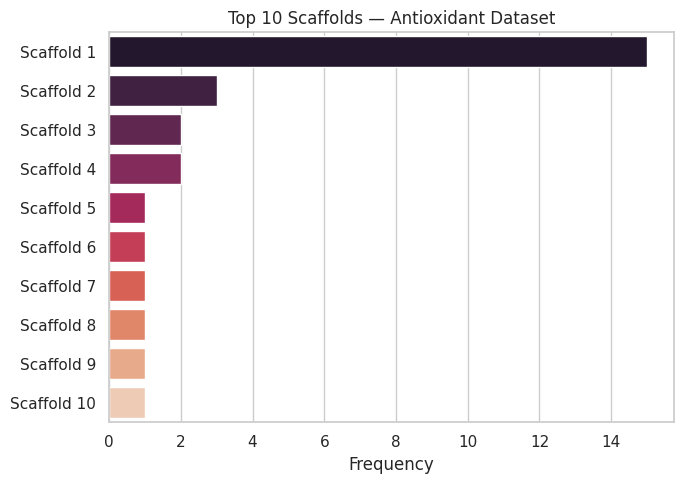

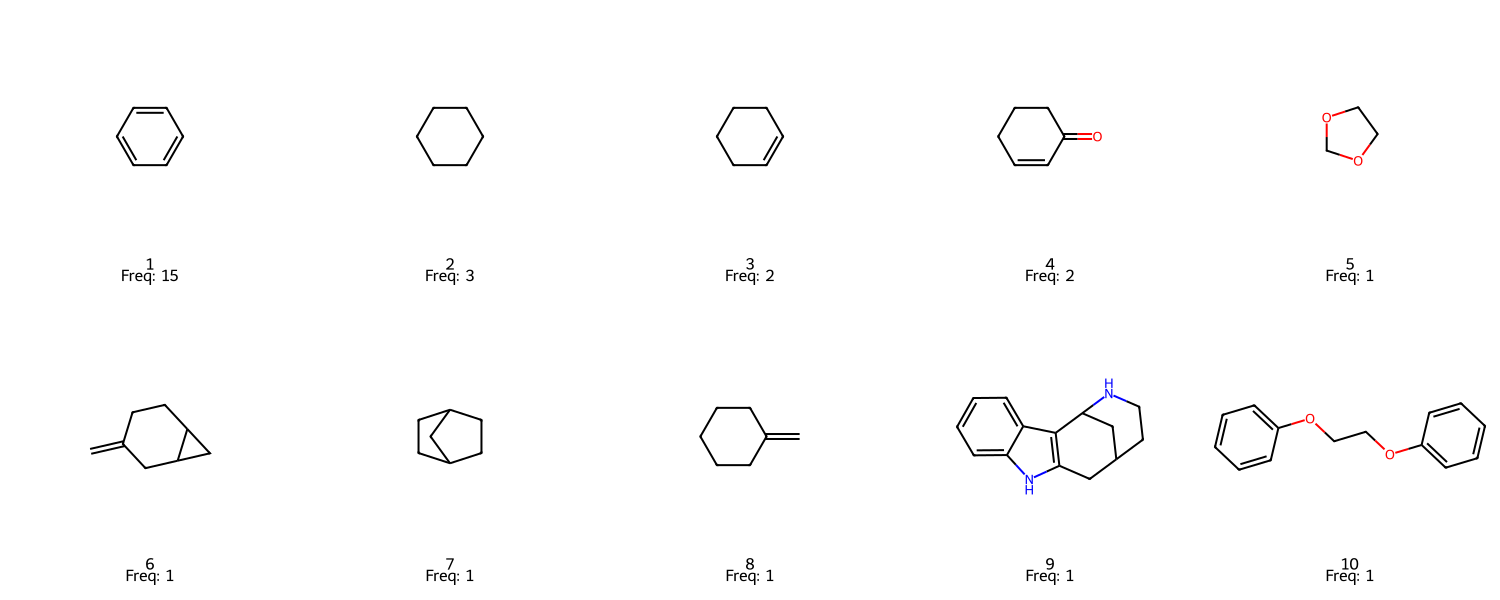

In [ ]:
antiox_df, antiox_counts, antiox_results = scaffold_analysis(
    antioxidant_df,
    smiles_col="SMILES",
    dataset_name="Antioxidant"
)

pd.DataFrame([antiox_results])
plot_top10_bar(antiox_counts, "Top 10 Scaffolds — Antioxidant Dataset")
plot_top10_structures(antiox_counts, "Scaffold Structures — Antioxidant Dataset")

In [ ]:
# Convert Counter to sorted list
sorted_scaffolds = sorted(antiox_counts.items(), key=lambda x: x[1], reverse=True)

# Top 10 scaffold IDs
top10_scaffolds = [sc[0] for sc in sorted_scaffolds[:10]]

# Function to extract compounds for a given Bemis–Murcko scaffold
def get_compounds_for_scaffold(df, scaffold, n=None):
    subset = df[df["BM_SCAFFOLD"] == scaffold]
    if n:
        return subset.head(n)
    return subset

results = {}

# Scaffold 1 → top 3 compounds
results[f"Scaffold_{top10_scaffolds[0]}_top3"] = get_compounds_for_scaffold(
    antiox_df, top10_scaffolds[0], n=3
)

# Scaffold 2–4 → top 2 compounds
for sc in top10_scaffolds[1:4]:
    results[f"Scaffold_{sc}_top2"] = get_compounds_for_scaffold(
        antiox_df, sc, n=2
    )

# Scaffold 5–10 → top 1 compound
for sc in top10_scaffolds[4:10]:
    results[f"Scaffold_{sc}_top1"] = get_compounds_for_scaffold(
        antiox_df, sc, n=1
    )

# Display results
for key, value in results.items():
    print(f"\n=== {key} ===")
    display(value[["Name", "SMILES", "BM_SCAFFOLD"]])


=== Scaffold_c1ccccc1_top3 ===


,Name,SMILES,BM_SCAFFOLD
3,Benzyl alcohol,C1=CC=C(C=C1)CO,c1ccccc1
5,Phenylethyl Alcohol,C1=CC=C(C=C1)CCO,c1ccccc1
8,"Phenol, 4-ethyl-",CCC1=CC=C(C=C1)O,c1ccccc1



=== Scaffold_C1CCCCC1_top2 ===


,Name,SMILES,BM_SCAFFOLD
11,"Cyclohexanol, 1-ethenyl-",C=CC1(CCCCC1)O,C1CCCCC1
23,"1,2-Cyclohexanediol, 1-methyl-4-(1-methylethyl)-",CC(C)C1CCC(C(C1)O)(C)O,C1CCCCC1



=== Scaffold_C1=CCCCC1_top2 ===


...

,Name,SMILES,BM_SCAFFOLD
19,"2-Methyl-5-(propan-2-ylidene)cyclohexane-1,4-diol",CC1CC(C(=C(C)C)CC1O)O,C=C1CCCCC1



=== Scaffold_c1ccc2c3c([nH]c2c1)CC1CCNC3C1_top1 ===


,Name,SMILES,BM_SCAFFOLD
22,Dasycarpidol,CCC1C2CCN(C1C3=C(C2O)NC4=CC=CC=C43)C,c1ccc2c3c([nH]c2c1)CC1CCNC3C1



=== Scaffold_c1ccc(OCCOc2ccccc2)cc1_top1 ===


,Name,SMILES,BM_SCAFFOLD
42,"Benzene, 1,1'-[1,2-ethanediylbis(oxy)]bis-",C1=CC=C(C=C1)OCCOC2=CC=CC=C2,c1ccc(OCCOc2ccccc2)cc1



=== Scaffold_c1ccccc1_top3 ===


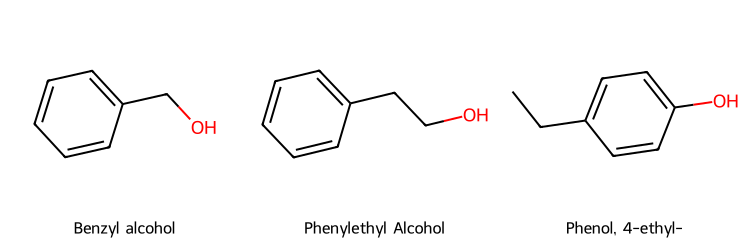


=== Scaffold_C1CCCCC1_top2 ===


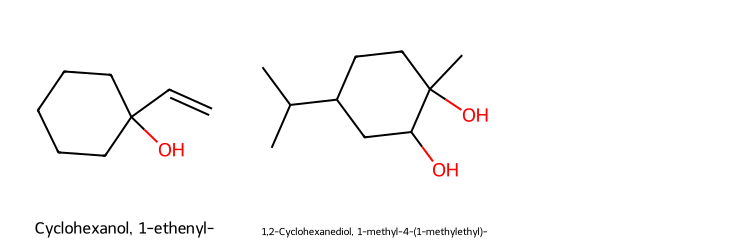


=== Scaffold_C1=CCCCC1_top2 ===


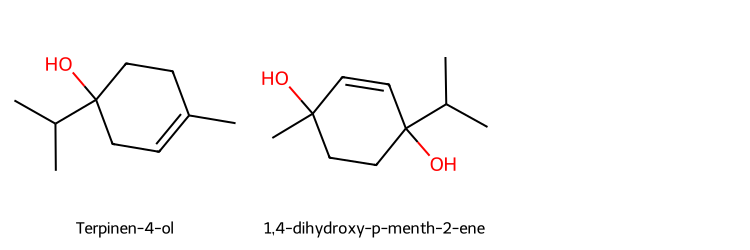


=== Scaffold_O=C1C=CCCC1_top2 ===


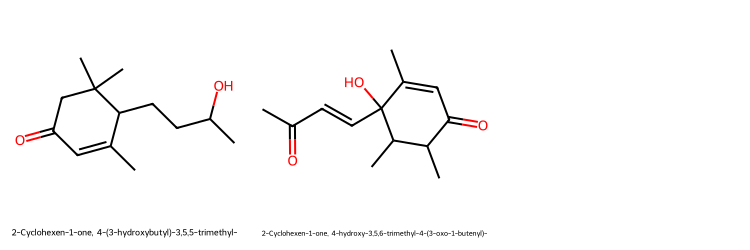


=== Scaffold_C1COCO1_top1 ===


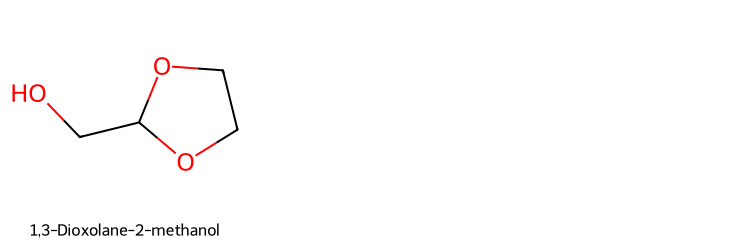


=== Scaffold_C=C1CCC2CC2C1_top1 ===


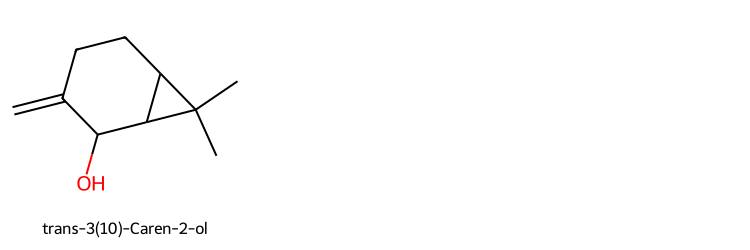


=== Scaffold_C1CC2CCC1C2_top1 ===


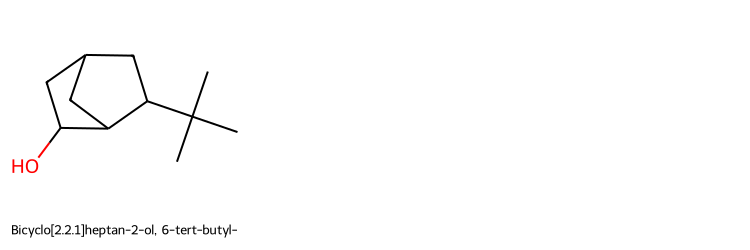


=== Scaffold_C=C1CCCCC1_top1 ===


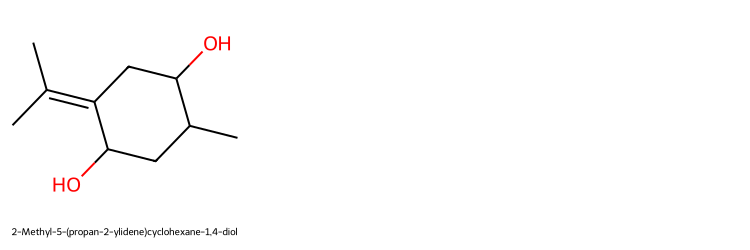


=== Scaffold_c1ccc2c3c([nH]c2c1)CC1CCNC3C1_top1 ===


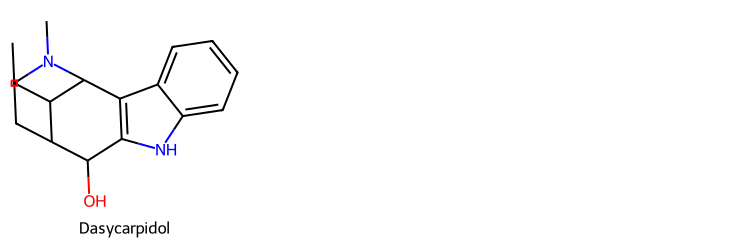


=== Scaffold_c1ccc(OCCOc2ccccc2)cc1_top1 ===


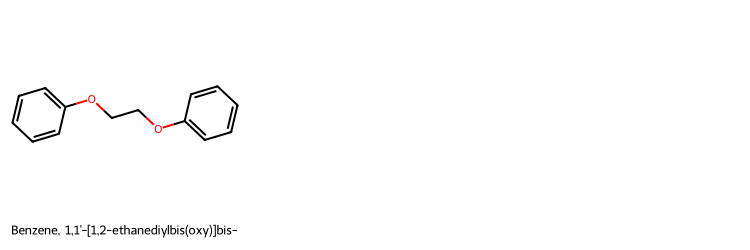

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Function to draw compounds from a subset DataFrame
def draw_compounds(df, smiles_col="SMILES", mols_per_row=3, size=(250, 250)):
    mols = [Chem.MolFromSmiles(smiles) for smiles in df[smiles_col] if Chem.MolFromSmiles(smiles)]
    if mols:
        img = Draw.MolsToGridImage(mols, molsPerRow=mols_per_row, subImgSize=size, legends=df['Name'].tolist())
        display(img)

# Loop through your results dictionary and draw compounds
for key, value in results.items():
    print(f"\n=== {key} ===")
    draw_compounds(value)

In [ ]:
from docx import Document

# Indices of your top 10 scaffolds in antioxidant_df
scaffold_indices = {
    "Scaffold 1: Phenol, 4-ethyl-": 8,
    "Scaffold 2: Cyclohexanol, 1-ethenyl": 11,
    "Scaffold 3: Terpinen-4-ol": 6,
    "Scaffold 4: 2-Cyclohexen-1-one, 4-(3-hydroxybutyl)-3,5,5-t...": 36,
    "Scaffold 5: 1,3-Dioxolane-2-methanol": 2,
    "Scaffold 6: trans-3(10)-Caren-2-ol": 17,
    "Scaffold 7: Bicyclo[2.2.1]heptan-2-ol, 6-tert-butyl-": 18,
    "Scaffold 8: 2-Methyl-5-(propan-2-ylidene)cyclohexane-1,4-diol": 19,
    "Scaffold 9: Dasycarpidol": 22,
    "Scaffold 10: Benzene, 1,1'-[1,2-ethanediylbis(oxy)]bis-": 42,
}

# Columns to include in the table (add Scaffold column)
columns = ["Scaffold", "Name", "R.T. (min)", "Similarity", "Formula", "Area", "Peak S/N", "Base Mass"]

# Create Word document
doc = Document()
doc.add_heading("Top 10 Scaffold Compounds — Antioxidant Dataset", 0)

# Create table with header row
table = doc.add_table(rows=1, cols=len(columns))
table.style = "Light List Accent 1"

# Add header
hdr_cells = table.rows[0].cells
for i, col in enumerate(columns):
    hdr_cells[i].text = col

# Add all compounds to the table
for scaffold_name, idx in scaffold_indices.items():
    compound = antioxidant_df.loc[idx]
    row_cells = table.add_row().cells
    row_cells[0].text = scaffold_name  # Scaffold name
    row_cells[1].text = str(compound["Name"])
    row_cells[2].text = str(compound["R.T. (min)"])
    row_cells[3].text = str(compound["Similarity"])
    row_cells[4].text = str(compound["Formula"])
    row_cells[5].text = str(compound["Area"])
    row_cells[6].text = str(compound["Peak S/N"])
    row_cells[7].text = str(compound["Base Mass"])

# Save Word document
doc.save("GC_antoxiTop10_Scaffold_Compounds_SingleTable.docx")
print("✅ Word document saved as 'Top10_Scaffold_Compounds_SingleTable.docx'")


✅ Word document saved as 'Top10_Scaffold_Compounds_SingleTable.docx'


#####Antimicrobial Scaffold Analysis

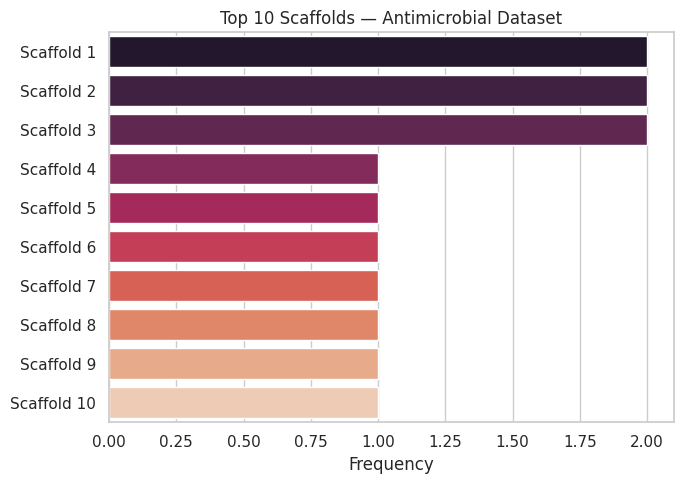

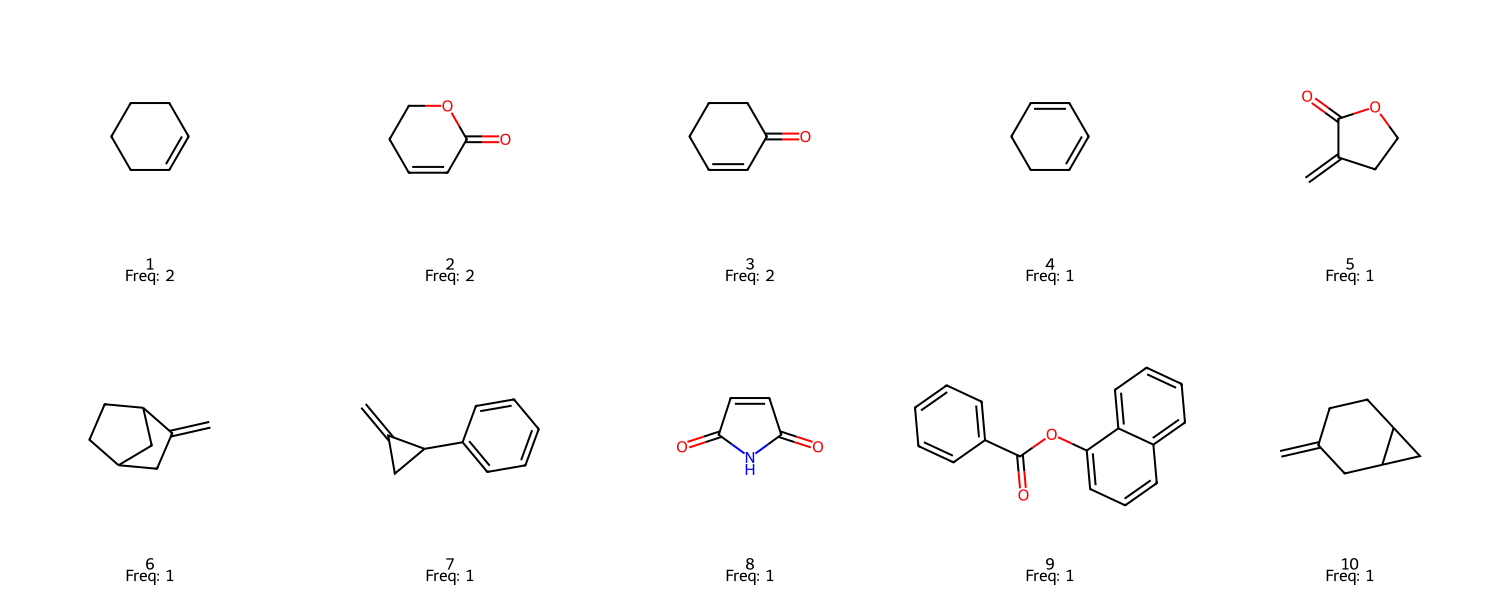

In [ ]:
antiM_df, antiM_counts, antiM_results = scaffold_analysis(
    antimicrobial_df,
    smiles_col="SMILES",
    dataset_name="Antimicrobial"
)

pd.DataFrame([antiM_results])
plot_top10_bar(antiM_counts, "Top 10 Scaffolds — Antimicrobial Dataset")
plot_top10_structures(antiM_counts, "Scaffold Structures — Antimicrobial Dataset")

In [ ]:
# Convert Counter to sorted list
sorted_scaffolds = sorted(antiM_counts.items(), key=lambda x: x[1], reverse=True)

# Top 10 scaffold IDs
top10_scaffolds = [sc[0] for sc in sorted_scaffolds[:10]]

# Function to extract compounds for a given Bemis–Murcko scaffold
def get_compounds_for_scaffold(df, scaffold, n=None):
    subset = df[df["BM_SCAFFOLD"] == scaffold]
    if n:
        return subset.head(n)
    return subset

results = {}

# Scaffold 1 → top 2 compounds
results[f"Scaffold_{top10_scaffolds[0]}_top2"] = get_compounds_for_scaffold(
    antiM_df, top10_scaffolds[0], n=2
)

# Scaffold 2–3 → top 2 compounds
for sc in top10_scaffolds[1:3]:
    results[f"Scaffold_{sc}_top2"] = get_compounds_for_scaffold(
        antiM_df, sc, n=2
    )

# Scaffold 4–10 → top 1 compound
for sc in top10_scaffolds[3:10]:
    results[f"Scaffold_{sc}_top1"] = get_compounds_for_scaffold(
        antiM_df, sc, n=1
    )

# Display results
for key, value in results.items():
    print(f"\n=== {key} ===")
    display(value[["Name", "SMILES", "BM_SCAFFOLD"]])


=== Scaffold_C1=CCCCC1_top2 ===


,Name,SMILES,BM_SCAFFOLD
0,D-Limonene,CC1=CCC(CC1)C(=C)C,C1=CCCCC1
6,Terpinen-4-ol,CC1=CCC(CC1)(C(C)C)O,C1=CCCCC1



=== Scaffold_O=C1C=CCCO1_top2 ===


,Name,SMILES,BM_SCAFFOLD
5,Dehydromevalonic lactone,CC1=CC(=O)OCC1,O=C1C=CCCO1
13,"2H-Pyran-2-one, 5,6-dihydro-4,6,6-trimethyl-",CC1=CC(=O)OC(C1)(C)C,O=C1C=CCCO1



=== Scaffold_O=C1C=CCCC1_top2 ===


...

,Name,SMILES,BM_SCAFFOLD
7,"1H-Pyrrole-2,5-dione, 3-ethyl-4-methyl-",CCC1=C(C(=O)NC1=O)C,O=C1C=CC(=O)N1



=== Scaffold_O=C(Oc1cccc2ccccc12)c1ccccc1_top1 ===


,Name,SMILES,BM_SCAFFOLD
9,"2-Methylbenzoic acid, 2,4-dichloronaphthyl-1 e...",CC1=CC=CC=C1C(=O)OC2=C(C=C(C3=CC=CC=C32)Cl)Cl,O=C(Oc1cccc2ccccc12)c1ccccc1



=== Scaffold_C=C1CCC2CC2C1_top1 ===


,Name,SMILES,BM_SCAFFOLD
10,trans-3(10)-Caren-2-ol,CC1(C2C1C(C(=C)CC2)O)C,C=C1CCC2CC2C1



=== Scaffold_C1=CCCCC1_top2 ===


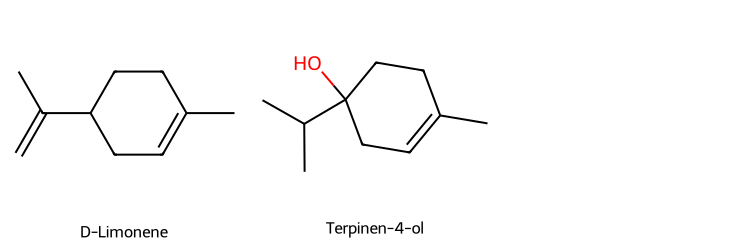


=== Scaffold_O=C1C=CCCO1_top2 ===


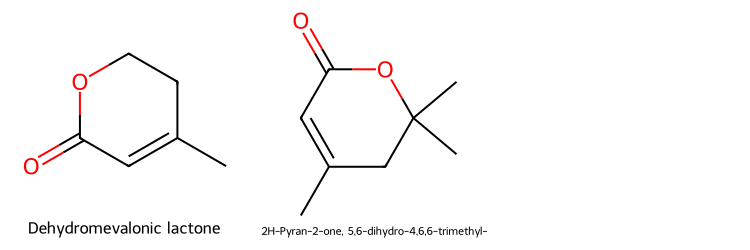


=== Scaffold_O=C1C=CCCC1_top2 ===


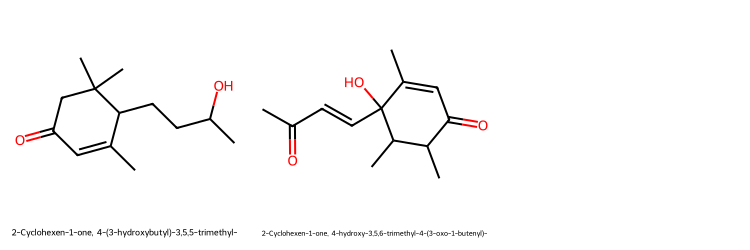


=== Scaffold_C1=CCCC=C1_top1 ===


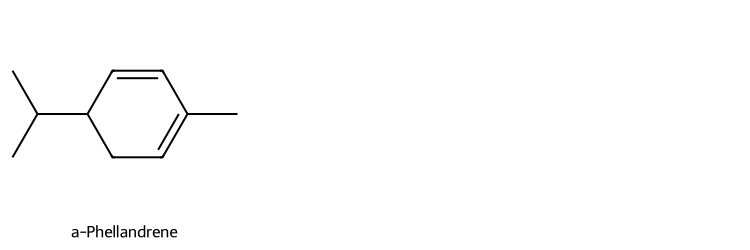


=== Scaffold_C=C1CCOC1=O_top1 ===


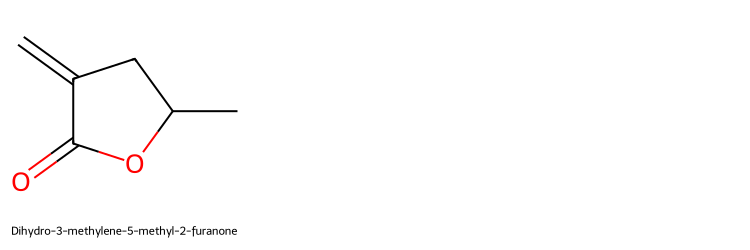


=== Scaffold_C=C1CC2CCC1C2_top1 ===


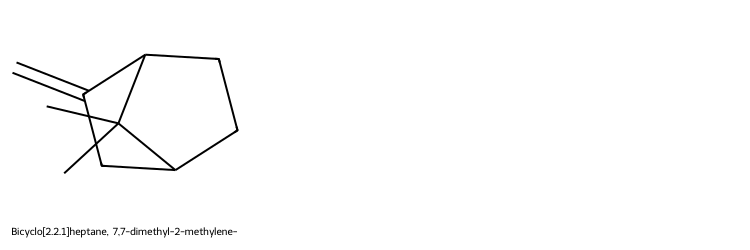


=== Scaffold_C=C1CC1c1ccccc1_top1 ===


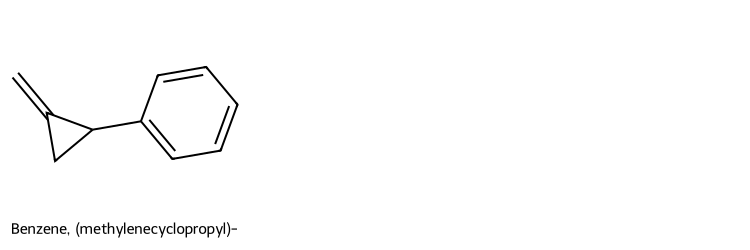


=== Scaffold_O=C1C=CC(=O)N1_top1 ===


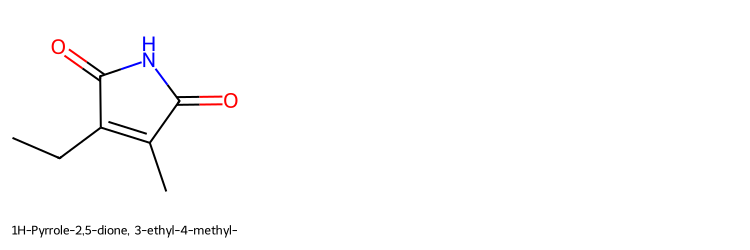


=== Scaffold_O=C(Oc1cccc2ccccc12)c1ccccc1_top1 ===


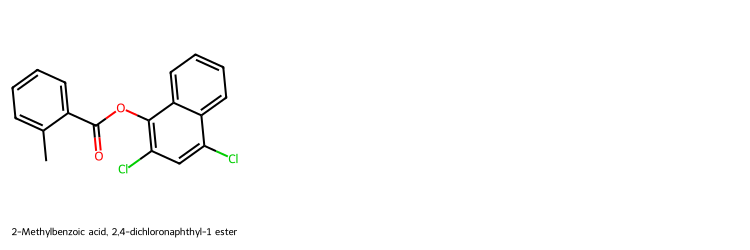


=== Scaffold_C=C1CCC2CC2C1_top1 ===


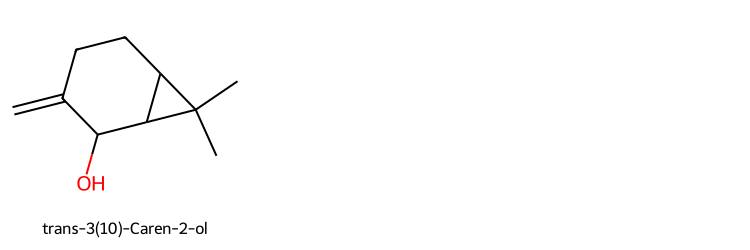

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Function to draw compounds from a subset DataFrame
def draw_compounds(df, smiles_col="SMILES", mols_per_row=3, size=(250, 250)):
    mols = [Chem.MolFromSmiles(smiles) for smiles in df[smiles_col] if Chem.MolFromSmiles(smiles)]
    if mols:
        img = Draw.MolsToGridImage(mols, molsPerRow=mols_per_row, subImgSize=size, legends=df['Name'].tolist())
        display(img)

# Loop through your results dictionary and draw compounds
for key, value in results.items():
    print(f"\n=== {key} ===")
    draw_compounds(value)

In [ ]:
from docx import Document

# Indices of your top 10 scaffolds in antimicrobial_df
scaffold_indices = {
    "Scaffold 1: ": 0,
    "Scaffold 2: ": 6,
    "Scaffold 3: ": 13,
    "Scaffold 4: ": 19,
    "Scaffold 5: ": 1,
    "Scaffold 6: ": 2,
    "Scaffold 7: ": 4,
    "Scaffold 8: ": 7,
    "Scaffold 9: ": 9,
    "Scaffold 10:": 10,
}

# Columns to include in the table (add Scaffold column)
columns = ["Scaffold", "Name", "R.T. (min)", "Similarity", "Formula", "Area", "Peak S/N", "Base Mass"]

# Create Word document
doc = Document()
doc.add_heading("Top 10 Scaffold Compounds — Antimicrobial Dataset", 0)

# Create table with header row
table = doc.add_table(rows=1, cols=len(columns))
table.style = "Light List Accent 1"

# Add header
hdr_cells = table.rows[0].cells
for i, col in enumerate(columns):
    hdr_cells[i].text = col

# Add all compounds to the table
for scaffold_name, idx in scaffold_indices.items():
    compound = antimicrobial_df.loc[idx]
    row_cells = table.add_row().cells
    row_cells[0].text = scaffold_name  # Scaffold name
    row_cells[1].text = str(compound["Name"])
    row_cells[2].text = str(compound["R.T. (min)"])
    row_cells[3].text = str(compound["Similarity"])
    row_cells[4].text = str(compound["Formula"])
    row_cells[5].text = str(compound["Area"])
    row_cells[6].text = str(compound["Peak S/N"])
    row_cells[7].text = str(compound["Base Mass"])

# Save Word document
doc.save("GC_antMTop10_Scaffold_Compounds_SingleTable.docx")
print("✅ Word document saved as 'Top10_Scaffold_Compounds_SingleTable.docx'")

✅ Word document saved as 'Top10_Scaffold_Compounds_SingleTable.docx'


##### Cytotoxic Scaffold Analysis

In [ ]:
def plot_top5_bar(scaffold_counts, title):
    topN = scaffold_counts.most_common(10)  # change to top 10
    n = len(topN)

    if n == 0:
        print("No scaffolds to plot.")
        return

    labels = [f"Scaffold {i+1}" for i in range(n)]
    freqs = [c for _, c in topN]

    plt.figure(figsize=(7,5))
    cmap = sns.color_palette("rocket", n)
    sns.barplot(x=freqs, y=labels, palette=cmap)
    plt.xlabel("Frequency")
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_top5_structures(scaffold_counts, title):
    topN = scaffold_counts.most_common(10)
    n = len(topN)

    if n == 0:
        print("No scaffolds to display.")
        return

    scaffolds = [Chem.MolFromSmiles(s) for s,_ in topN]
    labels = [f"{i+1}\nFreq: {c}" for i, (_, c) in enumerate(topN)]

    img = Draw.MolsToGridImage(
        scaffolds,
        legends=labels,
        molsPerRow=min(7, n),
        subImgSize=(300,300)
    )
    display(img)

In [ ]:
cyto_df, cyto_counts, cyto_results = scaffold_analysis(cytotoxic_df, smiles_col="SMILES", dataset_name="Cytotoxic")

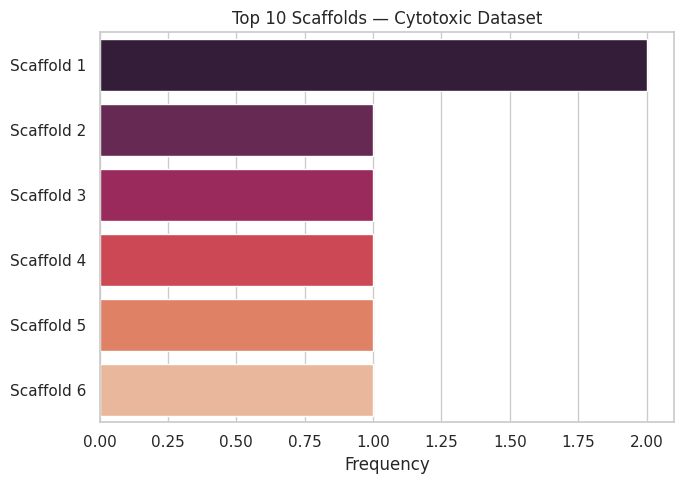

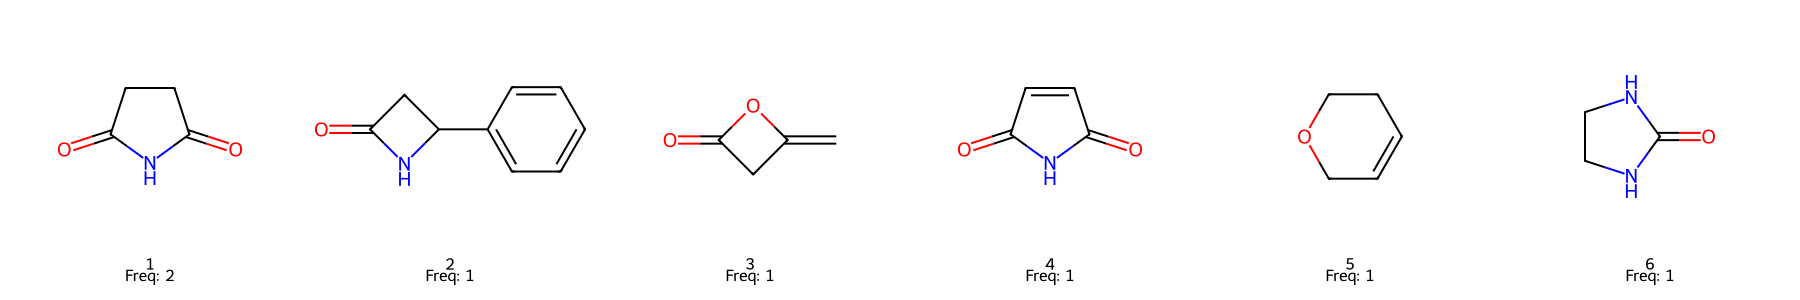

In [ ]:
plot_top5_bar(cyto_counts, "Top 10 Scaffolds — Cytotoxic Dataset")
plot_top5_structures(cyto_counts, "Scaffold Structures — Cytotoxic Dataset")

In [ ]:
# Loop through all scaffolds and extract compounds
cyto_results = {}

for scaffold_smiles in cyto_counts:
    compounds = cyto_df[cyto_df["BM_SCAFFOLD"] == scaffold_smiles]
    cyto_results[scaffold_smiles] = compounds

# Display compounds for all scaffolds
for i, (scaffold, compounds) in enumerate(cyto_results.items()):
    print(f"\n=== Scaffold {i+1}: {scaffold} ===")
    display(compounds[["Name", "SMILES", "BM_SCAFFOLD"]])


=== Scaffold 1: O=C1CC(c2ccccc2)N1 ===


,Name,SMILES,BM_SCAFFOLD
4,"2-Azetidinone, 1-tert-butyl-3,3-dimethyl-4-phe...",CC1(C(N(C1=O)C(C)(C)C)C2=CC=CC=C2)C,O=C1CC(c2ccccc2)N1



=== Scaffold 2: O=C1CCC(=O)N1 ===


,Name,SMILES,BM_SCAFFOLD
5,"Pyrrolidine-1-acetonitrile, 2,5-dioxo-",C1CC(=O)N(C1=O)CC#N,O=C1CCC(=O)N1
6,Succinimide,C1CC(=O)NC1=O,O=C1CCC(=O)N1



=== Scaffold 3: C=C1CC(=O)O1 ===


...

,Name,SMILES,BM_SCAFFOLD
9,"1H-Pyrrole-2,5-dione, 3-ethyl-4-methyl-",CCC1=C(C(=O)NC1=O)C,O=C1C=CC(=O)N1



=== Scaffold 5: C1=CCOCC1 ===


,Name,SMILES,BM_SCAFFOLD
10,"Acetamide, N-(2-ethoxy-3,6-dihydro-6-methyl-2H...",CCOC1C(C=CC(O1)C)NC(=O)C,C1=CCOCC1



=== Scaffold 6: O=C1NCCN1 ===


,Name,SMILES,BM_SCAFFOLD
12,2-Imidazolidinone,C1CNC(=O)N1,O=C1NCCN1



=== Scaffold 1: O=C1CC(c2ccccc2)N1 ===


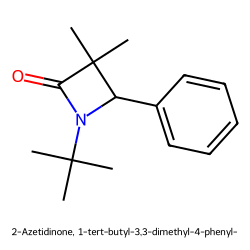


=== Scaffold 2: O=C1CCC(=O)N1 ===


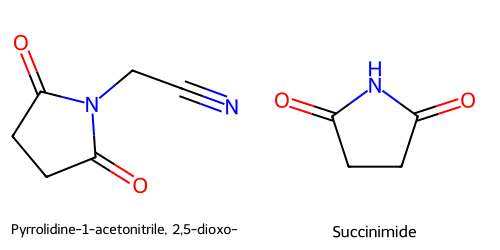


=== Scaffold 3: C=C1CC(=O)O1 ===


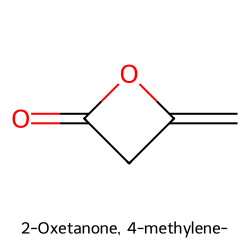


=== Scaffold 4: O=C1C=CC(=O)N1 ===


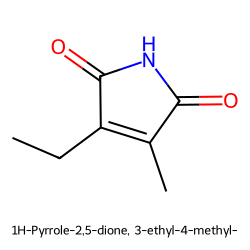


=== Scaffold 5: C1=CCOCC1 ===


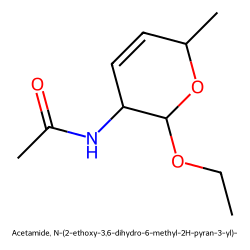


=== Scaffold 6: O=C1NCCN1 ===


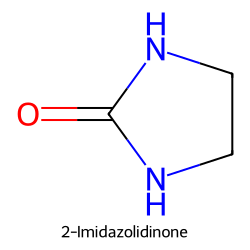

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw

# Loop through all scaffolds in cyto_counts
for i, scaffold_smiles in enumerate(cyto_counts):
    compounds = cyto_df[cyto_df["BM_SCAFFOLD"] == scaffold_smiles]
    mols = [Chem.MolFromSmiles(smiles) for smiles in compounds["SMILES"] if Chem.MolFromSmiles(smiles)]

    if not mols:
        continue  # skip if no valid molecules

    # Prepare labels with compound names
    labels = compounds["Name"].tolist()

    # Display scaffold and compounds
    print(f"\n=== Scaffold {i+1}: {scaffold_smiles} ===")
    img = Draw.MolsToGridImage(
        mols,
        legends=labels,
        molsPerRow=min(5, len(mols)),  # 5 per row
        subImgSize=(250,250)
    )
    display(img)


In [ ]:
from docx import Document

# Indices of your top 10 scaffolds in antimicrobial_df
scaffold_indices = {
    "Scaffold 1: ": 5,
    "Scaffold 2: ": 6,
    "Scaffold 3: ": 4,
    "Scaffold 4: ": 8,
    "Scaffold 5: ": 9,
    "Scaffold 6: ": 10,
    "Scaffold 10:": 12,
}

# Columns to include in the table (add Scaffold column)
columns = ["Scaffold", "Name", "R.T. (min)", "Similarity", "Formula", "Area", "Peak S/N", "Base Mass"]

# Create Word document
doc = Document()
doc.add_heading("Top 10 Scaffold Compounds — cytotoxic Dataset", 0)

# Create table with header row
table = doc.add_table(rows=1, cols=len(columns))
table.style = "Light List Accent 1"

# Add header
hdr_cells = table.rows[0].cells
for i, col in enumerate(columns):
    hdr_cells[i].text = col

# Add all compounds to the table
for scaffold_name, idx in scaffold_indices.items():
    compound = cytotoxic_df.loc[idx]
    row_cells = table.add_row().cells
    row_cells[0].text = scaffold_name  # Scaffold name
    row_cells[1].text = str(compound["Name"])
    row_cells[2].text = str(compound["R.T. (min)"])
    row_cells[3].text = str(compound["Similarity"])
    row_cells[4].text = str(compound["Formula"])
    row_cells[5].text = str(compound["Area"])
    row_cells[6].text = str(compound["Peak S/N"])
    row_cells[7].text = str(compound["Base Mass"])

# Save Word document
doc.save("GC_cytotoxicTop10_Scaffold_Compounds_SingleTable.docx")
print("✅ Word document saved as 'cyto_Top10_Scaffold_Compounds_SingleTable.docx'")

✅ Word document saved as 'cyto_Top10_Scaffold_Compounds_SingleTable.docx'


#### FULL SCAFFOLD VISUALIZATION SUITE

In [ ]:
def plot_top10_bar(scaffold_counts, title="Top 10 Scaffolds"):
    df = pd.DataFrame(
        scaffold_counts.most_common(10),
        columns=["Scaffold", "Frequency"]
    )

    if df.empty:
        print("⚠ No valid scaffolds to plot.")
        return

    plt.figure(figsize=(8, 6))
    plt.barh(df["Scaffold"], df["Frequency"])
    plt.gca().invert_yaxis()
    plt.title(title, fontsize=15)
    plt.xlabel("Frequency", fontsize=13)
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_top10_structures(scaffold_counts, title="Top 10 Scaffold Structures"):
    top10 = scaffold_counts.most_common(10)
    if len(top10) == 0:
        print("⚠ No scaffolds to visualize.")
        return

    scaffolds = []
    legends = []

    for i, (scaf, freq) in enumerate(top10, start=1):
        mol = Chem.MolFromSmiles(scaf)
        if mol:
            scaffolds.append(mol)
            legends.append(f"{i}\nFreq: {freq}")

    img = Draw.MolsToGridImage(
        scaffolds,
        molsPerRow=5,
        subImgSize=(300, 300),
        legends=legends
    )

    plt.figure(figsize=(15, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()

In [ ]:
def plot_scaffold_pie(scaffold_counts, title="Scaffold Distribution"):
    df = pd.DataFrame(scaffold_counts.most_common(10),
                      columns=["Scaffold", "Frequency"])
    if df.empty:
        print("⚠ No scaffolds for pie chart.")
        return

    plt.figure(figsize=(8, 8))
    plt.pie(df["Frequency"], labels=df["Scaffold"], autopct="%1.1f%%")
    plt.title(title, fontsize=16)
    plt.show()

In [ ]:
def compare_entropy(results_list):
    df = pd.DataFrame(results_list)

    plt.figure(figsize=(8,6))
    plt.bar(df["Dataset"], df["Shannon entropy"], color="gray")
    plt.ylabel("Shannon Entropy", fontsize=13)
    plt.title("Scaffold Diversity (Shannon Entropy)", fontsize=15)
    plt.show()

##### VENN DIAGRAM — Shared Scaffolds Across the 3 Bioactivities

In [ ]:
pip install matplotlib-venn

In [ ]:
from matplotlib_venn import venn3

def venn_scaffolds(a_counts, b_counts, c_counts,
                   labels=("Antioxidant", "Antimicrobial", "Cytotoxic")):

    setA = set(a_counts.keys())
    setB = set(b_counts.keys())
    setC = set(c_counts.keys())

    plt.figure(figsize=(8,8))
    venn3([setA, setB, setC], set_labels=labels)
    plt.title("Scaffold Overlap Across Bioactivities", fontsize=15)
    plt.show()

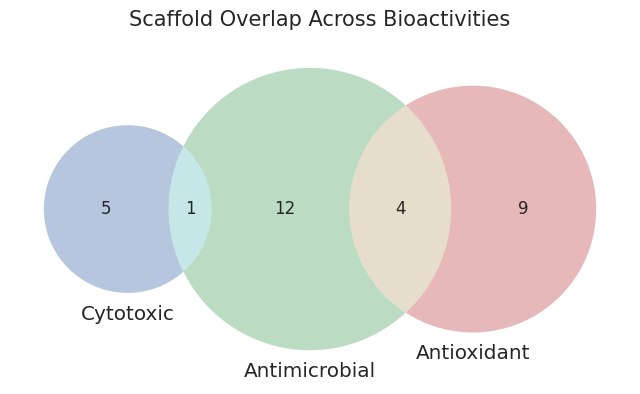

In [ ]:
venn_scaffolds(antiox_counts, antiM_counts, cyto_counts)

In [ ]:
from matplotlib_venn import venn3

def venn_scaffolds(a_counts, b_counts, c_counts,
                   labels=("Antioxidant", "Antimicrobial", "Cytotoxic")):

    setA = set(a_counts.keys())
    setB = set(b_counts.keys())
    setC = set(c_counts.keys())

    plt.figure(figsize=(8,8))
    venn3([setA, setB, setC], set_labels=labels)
    plt.title("Scaffold Overlap Across Bioactivities", fontsize=15)
    plt.show()

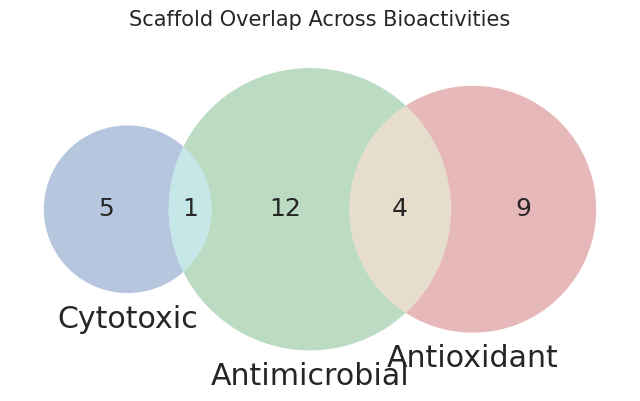

In [ ]:
venn_scaffolds(antiox_counts, antiM_counts, cyto_counts)

##### SCAFFOLD HEATMAP — Counts Across All 3 Datasets

In [ ]:
def scaffold_heatmap(a_counts, b_counts, c_counts):
    # union of all scaffolds
    scaffolds = sorted(list(set(a_counts.keys()) |
                            set(b_counts.keys()) |
                            set(c_counts.keys())))

    data = []
    for scaf in scaffolds:
        data.append([
            a_counts.get(scaf, 0),
            b_counts.get(scaf, 0),
            c_counts.get(scaf, 0),
        ])

    df = pd.DataFrame(data, index=scaffolds,
                      columns=["Antioxidant", "Antimicrobial", "Cytotoxic"])

    plt.figure(figsize=(10, max(6, len(scaffolds)*0.25)))
    sns.heatmap(df, cmap="viridis", annot=False)
    plt.title("Scaffold Occurrence Heatmap", fontsize=16)
    plt.xlabel("Dataset")
    plt.ylabel("Scaffold")
    plt.show()

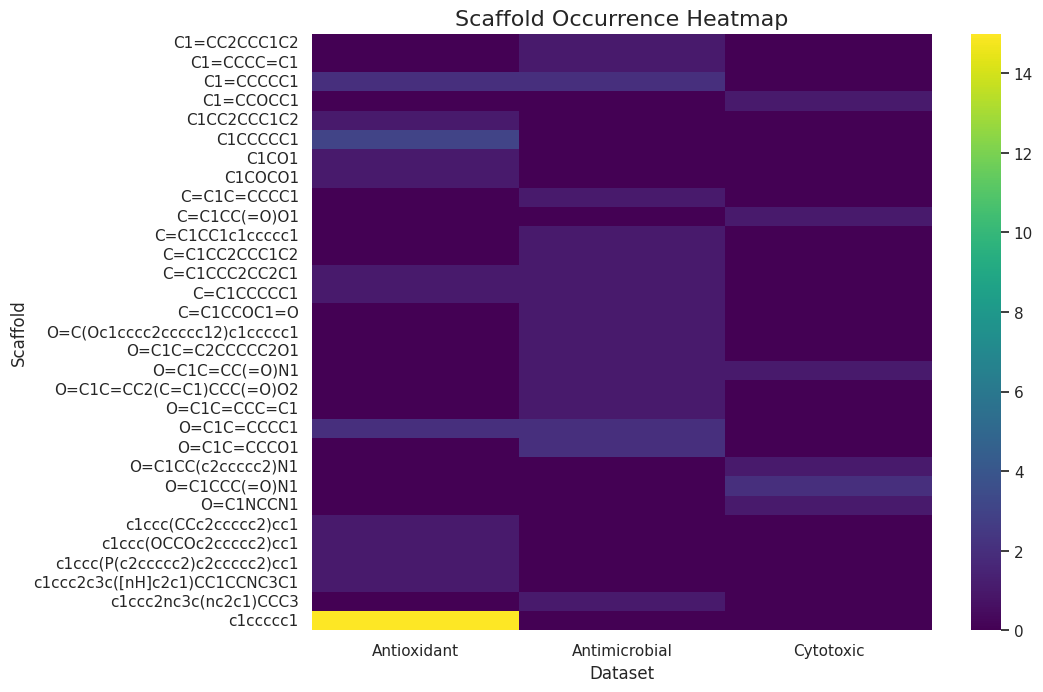

In [ ]:
scaffold_heatmap(antiox_counts, antiM_counts, cyto_counts)

In [ ]:
def diversity_table(results_list):
    df = pd.DataFrame(results_list)
    return df[[
        "Dataset", "Molecules (N)",
        "Unique scaffolds (Ns)", "Singleton scaffolds (Nss)", "Cyclic skeletons (Ncsk)",
        "Ns/N", "Nss/N", "Ncsk/N",
        "Scaffold diversity (N/M)", "Singleton diversity (Nsing/M)",
        "Shannon entropy"
    ]]

##### SCAFFOLD DIVERSITY TABLE (Ns/N, Nss/N, Ncsk/N)

This is directly ready for your Supplementary Table S3.

In [ ]:
diversity_table([antiox_results, antiM_results, cyto_results])

,Dataset,Molecules (N),Unique scaffolds (Ns),Singleton scaffolds (Nss),Cyclic skeletons (Ncsk),Ns/N,Nss/N,Ncsk/N,Scaffold diversity (N/M),Singleton diversity (Nsing/M),Shannon entropy
0,Antioxidant,31.0,13.0,9.0,29.0,0.419355,0.290323,0.935484,0.419355,0.290323,2.781350
1,Antimicrobial,20.0,17.0,14.0,18.0,0.850000,0.700000,0.900000,0.850000,0.700000,4.021928
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def scaffold_frequency_scatter(scaffold_counts, title):
    freqs = list(scaffold_counts.values())
    scaffolds = list(scaffold_counts.keys())

    plt.figure(figsize=(8,6))
    plt.scatter(range(len(freqs)), freqs)
    plt.title(title)
    plt.xlabel("Scaffold Index")
    plt.ylabel("Frequency")
    plt.show()

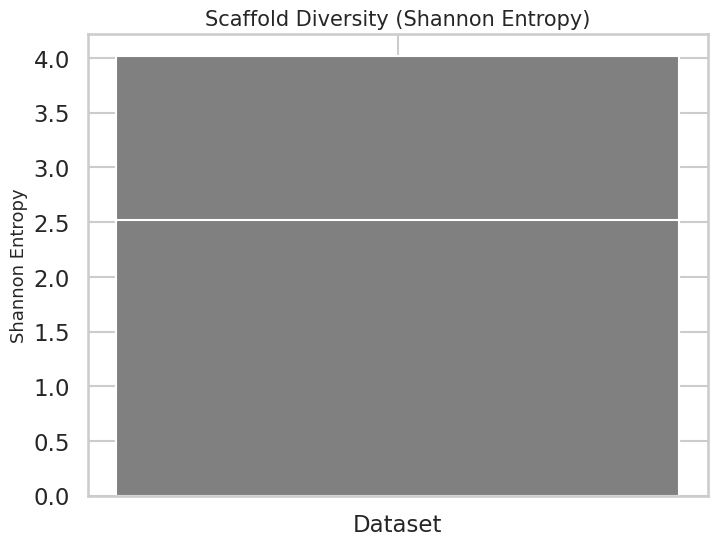

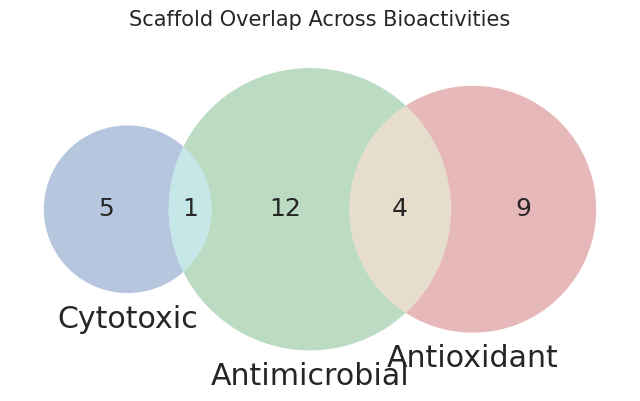

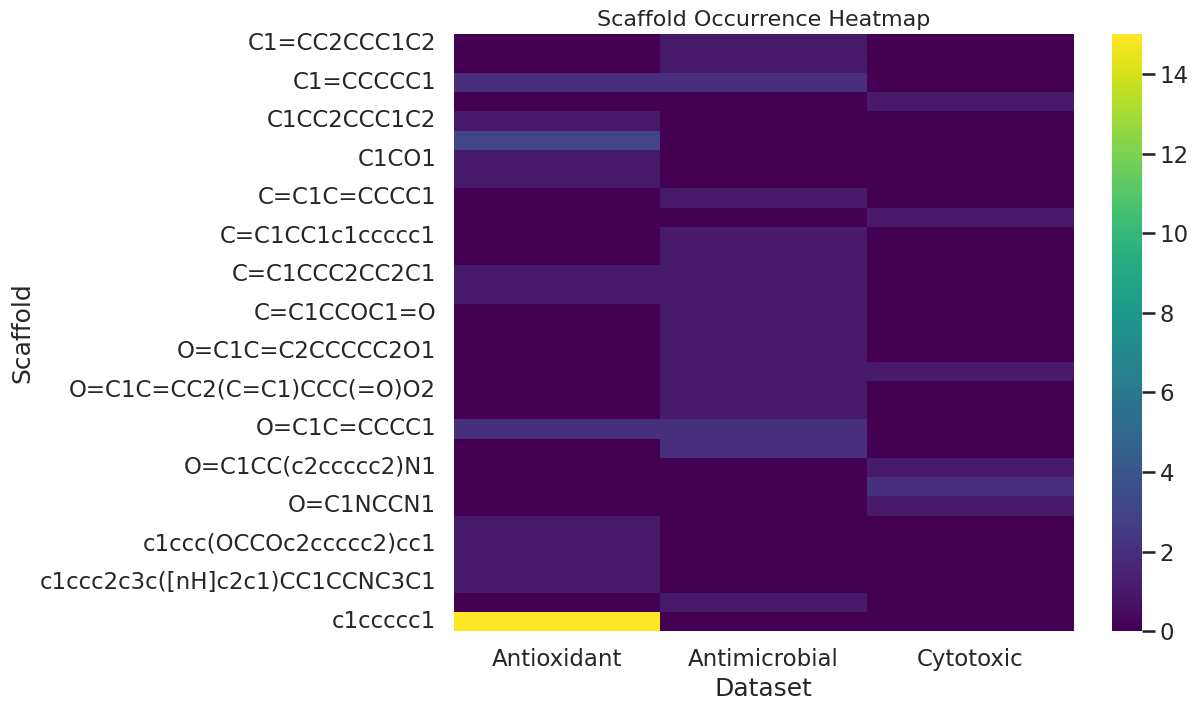

,Dataset,Molecules (N),Unique scaffolds (Ns),Singleton scaffolds (Nss),Cyclic skeletons (Ncsk),Ns/N,Nss/N,Ncsk/N,Scaffold diversity (N/M),Singleton diversity (Nsing/M),Shannon entropy
0,Dataset,31,13,9,29,0.419355,0.290323,0.935484,0.419355,0.290323,2.781350
1,Dataset,20,17,14,18,0.850000,0.700000,0.900000,0.850000,0.700000,4.021928
2,Dataset,7,6,5,7,0.857143,0.714286,1.000000,0.857143,0.714286,2.521641


In [ ]:
compare_entropy([antiox_results, antiM_results, cyto_results])
venn_scaffolds(antiox_counts, antiM_counts, cyto_counts)
scaffold_heatmap(antiox_counts, antiM_counts, cyto_counts)
diversity_table([antiox_results, antiM_results, cyto_results])

In [ ]:
import plotly.express as px

def sunburst_scaffolds(df):
    df_temp = df.copy()
    df_temp["Scaffold"] = df_temp["BM_SCAFFOLD"]

    fig = px.sunburst(
        df_temp,
        path=["Scaffold", "CYCLIC_SKEL"],
        title="Scaffold → Cyclic Skeleton Hierarchy",
        width=700,
        height=700
    )
    fig.show()

In [ ]:
sunburst_scaffolds(cyto_df)


In [ ]:
import plotly.graph_objects as go

def scaffold_force_map(scaffold_counts):
    scaffolds = list(scaffold_counts.keys())
    fp_matrix = []

    for s in scaffolds:
        mol = Chem.MolFromSmiles(s)
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 512)
            arr = np.zeros((1,))
            DataStructs.ConvertToNumpyArray(fp, arr)
            fp_matrix.append(arr)

    fp_matrix = np.array(fp_matrix)
    dist = np.sqrt(((fp_matrix[:,None] - fp_matrix[None,:])**2).sum(-1))

    fig = go.Figure(data=go.Heatmap(
        z=dist,
        x=scaffolds,
        y=scaffolds,
        colorscale="Viridis"
    ))
    fig.update_layout(title="Scaffold Distance Map")
    fig.show()

In [ ]:
scaffold_force_map(antiox_counts)

[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator
[13:32:03] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import pandas as pd
import numpy as np
from collections import Counter
import math


def compute_bm_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def scaffold_analysis(df, smiles_col="SMILE"):

    df = df.copy()
    df["BM_Scaffold"] = df[smiles_col].apply(compute_bm_scaffold)

    # Remove None
    df = df[df["BM_Scaffold"].notna()]

    # Total molecules
    M = len(df)

    # List of scaffolds
    scaffolds = df["BM_Scaffold"].tolist()

    # Unique scaffolds
    unique_scaffolds = set(scaffolds)
    N = len(unique_scaffolds)

    # Frequency count
    freq = Counter(scaffolds)

    # Singleton scaffolds
    singleton_scaffolds = [s for s, c in freq.items() if c == 1]
    Nsing = len(singleton_scaffolds)

    # Cyclic skeletons: scaffolds containing a ring
    Ncsk = sum(1 for s in unique_scaffolds if Chem.MolFromSmiles(s).GetRingInfo().NumRings() > 0)

    # Proportions
    scaffold_diversity = N / M
    scaffold_novelty = Nsing / M
    cyclic_proportion = Ncsk / M

    # Shannon entropy
    probabilities = [c/M for c in freq.values()]
    SE = -sum(p * math.log(p, 2) for p in probabilities)

    # Final summary dictionary
    summary = {
        "Total Molecules (M)": M,
        "Unique Scaffolds (N)": N,
        "Singleton Scaffolds (Nsing)": Nsing,
        "Cyclic Scaffolds (Ncsk)": Ncsk,
        "Scaffold Diversity (N/M)": scaffold_diversity,
        "Scaffold Novelty (Nsing/M)": scaffold_novelty,
        "Cyclic Skeleton Ratio (Ncsk/M)": cyclic_proportion,
        "Shannon Entropy": SE
    }

    # Prepare scaffold frequency table
    freq_df = pd.DataFrame(freq.items(), columns=["Scaffold", "Frequency"]).sort_values(
        "Frequency", ascending=False
    )

    return summary, freq_df, df


In [ ]:
summary_antiox, freq_antiox, df_antiox_scaf = scaffold_analysis(df_antioxidant)
summary_antimicro, freq_antimicro, df_antimicro_scaf = scaffold_analysis(df_antimicrobial)
summary_other, freq_other, df_other_scaf = scaffold_analysis(df_other)

In [ ]:
summary_antiox

In [ ]:
freq_antiox

In [ ]:
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import math
import os

def visualize_top_scaffolds(freq_df, title="Top Scaffolds", out_dir="scaffold_images"):
    os.makedirs(out_dir, exist_ok=True)

    # Select top 10 scaffolds
    top10 = freq_df.head(10).reset_index(drop=True)

    # Draw scaffold images and save files
    images = []
    for i, row in top10.iterrows():
        smi = row["Scaffold"]
        mol = Chem.MolFromSmiles(smi)
        img = Draw.MolToImage(mol, size=(250,250))
        images.append(img)

        img.save(f"{out_dir}/scaffold_{i+1}.png")

    # --- PLOT A: Bar chart ---
    plt.figure(figsize=(8,5))
    plt.barh(top10.index+1, top10["Frequency"], color=plt.cm.plasma(np.linspace(0,1,10)))
    plt.gca().invert_yaxis()
    plt.xlabel("Frequency")
    plt.ylabel("Scaffold Rank")
    plt.title(title)
    plt.show()

    # --- PLOT B: 2x5 Scaffold grid ---
    fig, axes = plt.subplots(2,5, figsize=(15,6))
    fig.suptitle(f"{title} – Scaffold Structures", fontsize=16)

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i])
        ax.axis("off")
        ax.set_title(f"({i+1})\nFreq: {top10['Frequency'][i]}", fontsize=10)

    plt.tight_layout()
    plt.show()

    return top10

In [ ]:
top10_antiox = visualize_top_scaffolds(freq_antiox, "Antioxidant Scaffolds")
top10_antimicro = visualize_top_scaffolds(freq_antimicro, "Antimicrobial Scaffolds")
top10_other = visualize_top_scaffolds(freq_other, "Other Bioactivity Scaffolds")

TIC chromatogram

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/TIC.csv')

In [ ]:
print(data.head())

   Spectrum        Time           TIC
0         0  419.999993  2.291655e+06
1         1  420.099987  2.289645e+06
2         2  420.199980  2.287450e+06
3         3  420.299974  2.285396e+06
4         4  420.399968  2.283643e+06


In [ ]:
df = data

In [ ]:
print(df.columns)

Index(['Spectrum', 'Time', 'TIC'], dtype='object')


Detected Peaks (Retention Time in min and TIC %):
RT: 7.24 min, TIC: 5.1%
RT: 7.87 min, TIC: 8.8%
RT: 9.32 min, TIC: 13.0%
RT: 10.28 min, TIC: 7.3%
RT: 19.15 min, TIC: 5.3%
RT: 19.20 min, TIC: 5.7%
RT: 19.47 min, TIC: 7.2%
RT: 19.52 min, TIC: 8.4%
RT: 19.58 min, TIC: 54.8%
RT: 19.75 min, TIC: 33.0%
RT: 19.91 min, TIC: 7.1%
RT: 20.05 min, TIC: 7.5%
RT: 20.13 min, TIC: 7.2%
RT: 20.20 min, TIC: 6.9%
RT: 20.25 min, TIC: 6.6%
RT: 20.31 min, TIC: 7.2%
RT: 20.39 min, TIC: 7.3%
RT: 20.47 min, TIC: 7.1%
RT: 20.52 min, TIC: 7.7%
RT: 20.58 min, TIC: 8.0%
RT: 20.65 min, TIC: 8.7%
RT: 20.75 min, TIC: 10.3%
RT: 20.87 min, TIC: 8.7%
RT: 20.91 min, TIC: 8.7%
RT: 21.03 min, TIC: 14.2%
RT: 21.12 min, TIC: 100.0%
RT: 21.20 min, TIC: 61.8%
RT: 21.25 min, TIC: 71.4%
RT: 21.32 min, TIC: 25.5%
RT: 21.51 min, TIC: 15.5%
RT: 21.78 min, TIC: 9.5%
RT: 21.89 min, TIC: 9.4%
RT: 22.01 min, TIC: 8.9%
RT: 22.06 min, TIC: 11.4%
RT: 22.13 min, TIC: 9.7%
RT: 22.19 min, TIC: 8.5%
RT: 22.32 min, TIC: 9.2%
RT: 22.43 min, T

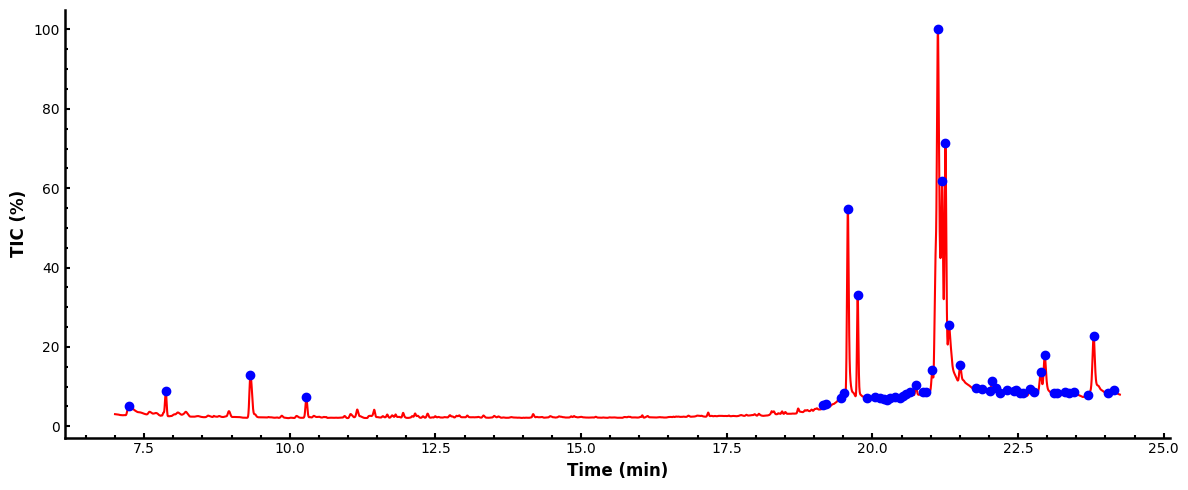

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# 1. Load & clean your data
# -----------------------------
df.columns = df.columns.str.strip()
time_col = "Time"
tic_col = "TIC"

df = df[[time_col, tic_col]]
df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
df[tic_col] = pd.to_numeric(df[tic_col], errors="coerce")
df = df.dropna()

# Convert time to minutes and TIC to percentage
df["Time_min"] = df[time_col] / 60
df["TIC_percent"] = (df[tic_col] / df[tic_col].max()) * 100

# -----------------------------
# 2. Detect peaks
# -----------------------------
# height: minimum TIC % to consider (e.g., 5% to ignore noise)
# distance: minimum distance between peaks in points
peaks, properties = find_peaks(df["TIC_percent"], height=5, distance=20)

# Extract peak retention times and TIC %
peak_times = df["Time_min"].iloc[peaks].values
peak_intensities = df["TIC_percent"].iloc[peaks].values

# -----------------------------
# 3. Print peak retention times
# -----------------------------
print("Detected Peaks (Retention Time in min and TIC %):")
for t, i in zip(peak_times, peak_intensities):
    print(f"RT: {t:.2f} min, TIC: {i:.1f}%")

# -----------------------------
# 4. Plot TIC with detected peaks
# -----------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["Time_min"], df["TIC_percent"], color="red", linewidth=1.5)
ax.plot(peak_times, peak_intensities, "o", color="blue", markersize=6)  # mark peaks in blue

ax.set_xlabel("Time (min)", fontsize=12, fontweight='bold')
ax.set_ylabel("TIC (%)", fontsize=12, fontweight='bold')

# Axes appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)

ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', width=1.5)

plt.tight_layout()
plt.show()

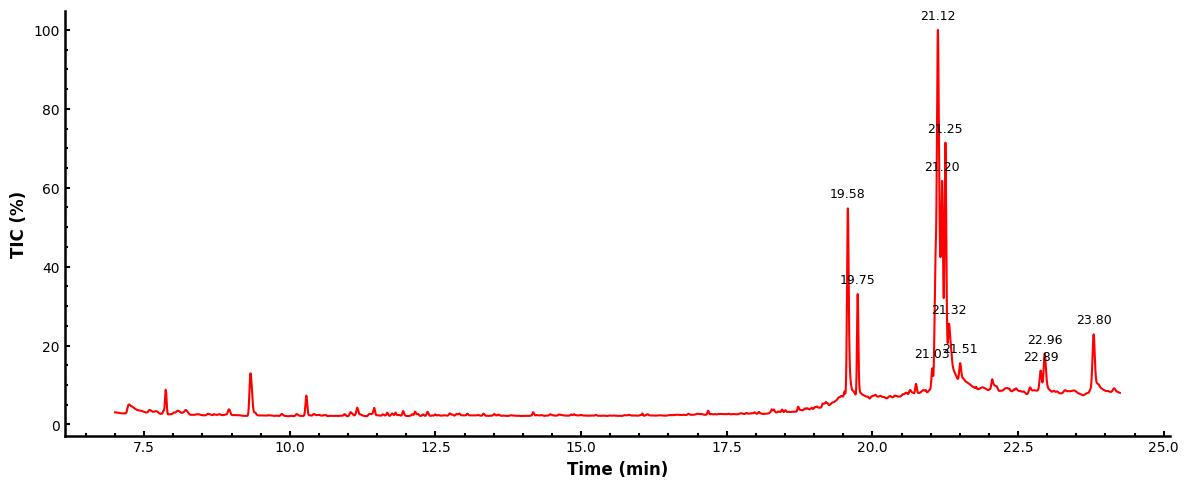

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# 1. Load & clean your data
# -----------------------------
df.columns = df.columns.str.strip()
time_col = "Time"
tic_col = "TIC"

df = df[[time_col, tic_col]]
df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
df[tic_col] = pd.to_numeric(df[tic_col], errors="coerce")
df = df.dropna()

# Convert time to minutes and TIC to percentage
df["Time_min"] = df[time_col] / 60
df["TIC_percent"] = (df[tic_col] / df[tic_col].max()) * 100

# -----------------------------
# 2. Detect peaks
# -----------------------------
peaks, properties = find_peaks(df["TIC_percent"], height=5, distance=20)

# Extract peak retention times and TIC %
peak_times = df["Time_min"].iloc[peaks].values
peak_intensities = df["TIC_percent"].iloc[peaks].values

# -----------------------------
# 3. Plot TIC with selective peak labels
# -----------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["Time_min"], df["TIC_percent"], color="red", linewidth=1.5)

# Label only peaks with TIC > 13%
for t, i in zip(peak_times, peak_intensities):
    if i > 13:  # threshold to avoid overlapping
        ax.text(t, i + 2, f"{t:.2f}", ha='center', va='bottom', fontsize=9, rotation=0, color="black")

# Axis labels
ax.set_xlabel("Time (min)", fontsize=12, fontweight='bold')
ax.set_ylabel("TIC (%)", fontsize=12, fontweight='bold')

# Axes appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)

# Minor ticks
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', width=1.5)

plt.tight_layout()
plt.show()

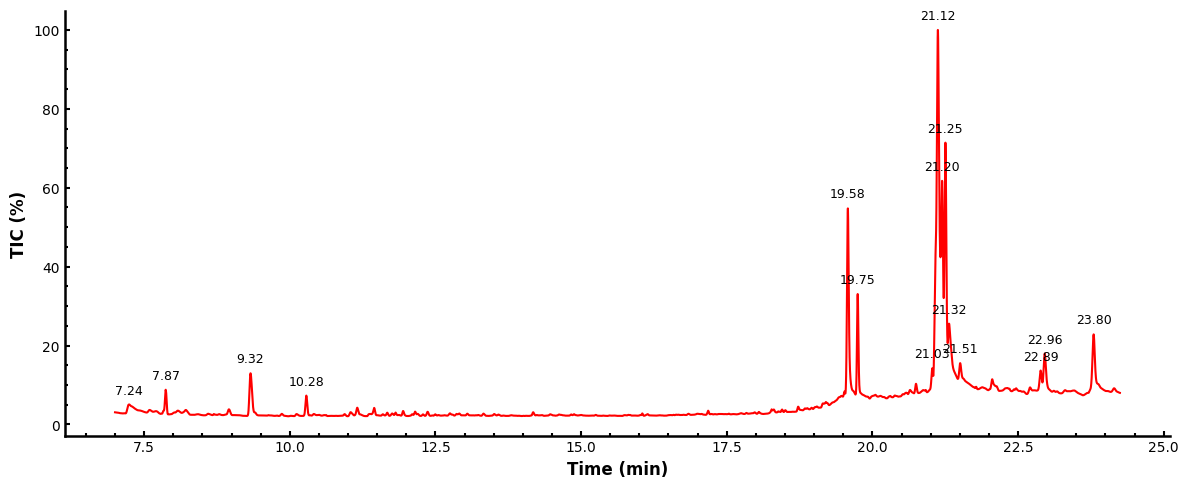

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# -----------------------------
# 1. Load & clean your data
# -----------------------------
df.columns = df.columns.str.strip()
time_col = "Time"
tic_col = "TIC"

df = df[[time_col, tic_col]]
df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
df[tic_col] = pd.to_numeric(df[tic_col], errors="coerce")
df = df.dropna()

# Convert time to minutes and TIC to percentage
df["Time_min"] = df[time_col] / 60
df["TIC_percent"] = (df[tic_col] / df[tic_col].max()) * 100

# -----------------------------
# 2. Detect peaks
# -----------------------------
peaks, properties = find_peaks(df["TIC_percent"], height=5, distance=20)

# Extract peak retention times and TIC %
peak_times = df["Time_min"].iloc[peaks].values
peak_intensities = df["TIC_percent"].iloc[peaks].values

# -----------------------------
# 3. Plot TIC with selective peak labels
# -----------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["Time_min"], df["TIC_percent"], color="red", linewidth=1.5)

# Label peaks: first 4 always, others only if TIC > 13%
for idx, (t, i) in enumerate(zip(peak_times, peak_intensities)):
    if idx < 4 or i > 13:  # first 4 peaks always, rest only >13%
        ax.text(t, i + 2, f"{t:.2f}", ha='center', va='bottom', fontsize=9, rotation=0, color="black")

# Axis labels
ax.set_xlabel("Time (min)", fontsize=12, fontweight='bold')
ax.set_ylabel("TIC (%)", fontsize=12, fontweight='bold')

# Axes appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)

# Minor ticks
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', width=1.5)

plt.tight_layout()
plt.show()